In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import warnings
import ipaddress

In [2]:
file_path = 'src/Hulk-NoDefense.csv'
chunk_size = 10000 
chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunks.append(chunk)

df_raw = pd.concat(chunks, ignore_index=True)
df_copy = df_raw.copy()

# Step 3: Data Preprocessing

In this section we are going to perfom the preprocessing phase, taking into account bad/missing values, categorical features management, unbalanced classes and normalization.

**Separation between data and target**  
Firstly, the dataset is divided in train_x (the data, whitout unnecessary columns), and train_y (the target value). Then train_y is encoded, changing 'BENIGN' into 0 and 'Hulk-NoDefense' into 1, because some machine learning models, including the Logistic Regressor, work only with numerical values.  

In [3]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

train_y = df_copy['Label']
train_y = label_encoder.fit_transform(train_y)  # to convert label values in 0 and 1
train_x = df_copy.drop(columns=['Label', 'Flow ID','Src IP', 'Dst IP','Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Subflow Bwd Packets'])

**Management of NaN/inf istances**  
To manage the problem of NaN/inf values, there's the necessity to understand why the "Flow Duration" is set to be equal to 0 and what can be performed to adjust the other parameters. It's not possible to remove those istances because they all are part of the benign class, so removing them means to increase the unbalancing problem too.  
The possible approaches are two: assuming 0 as a correct value, mainly due to a short connection with just 1 packet, or stating that 0 is not valid, modify it and recompute the affected fields. 

Since that only in those istances the flow consists of just 1 packet, the assumption is that 0 is a legit values, meaning that basically there's no flow if the connection contains only 1 packet. Thanks to this, the features "Flow Bytes/s" and "Flow Packet/s" that were equal to 'inf' are setted as the number of bytes in the packet and 1 respectively. Because there's no flow, 'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min' are all equal to 0. 

In [4]:
rows_null = [486712, 702344, 837046]
for row in rows_null:
    train_x.loc[row, 'Flow Bytes/s'] = (train_x.loc[row, 'Total Length of Fwd Packet'] + train_x.loc[row, 'Total Length of Bwd Packet'])
    train_x.loc[row, 'Flow Packets/s'] = 1
    train_x.loc[row, 'Flow IAT Mean'] = 0
    train_x.loc[row, 'Flow IAT Std'] = 0
    train_x.loc[row, 'Flow IAT Max'] = 0
    train_x.loc[row, 'Flow IAT Min'] = 0

display(train_x[train_x.isnull().any(axis=1)])

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min


**Categorical features**  
In the previous analysis , the results of the chi-square state that the categorical features are not related to the target value. However, in a field of cybersecurity and protection against Dos attack, could be relevant to understand if a particular, strange connection happens in office hour or not. To assest the impact of that phenomenon to the analysis, from 'Timestamp' three numerical features 'Hour', 'Weekday' and 'Month' were extracted.

In [5]:
train_x['Timestamp'] = pd.to_datetime(train_x['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
train_x['Hour'] = train_x['Timestamp'].dt.hour
train_x['Weekday'] = train_x['Timestamp'].dt.weekday
train_x['Month'] = train_x['Timestamp'].dt.month  

train_x=train_x.drop('Timestamp', axis=1)
display(train_x.head())

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Hour,Weekday,Month
0,34700,80,6,1397,7,6,377.0,11192.0,377.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3,2
1,34702,80,6,1438,7,6,369.0,11192.0,369.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3,2
2,34704,80,6,1753,7,6,377.0,11192.0,377.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3,2
3,34706,80,6,3166,7,6,369.0,11192.0,369.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3,2
4,34708,80,6,1094,9,7,363.0,11192.0,363.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,3,2


## Analysis on rebalancing problem with an hybrid approach

The final step of the preprocessing phase addresses the issue of imbalanced classes. Initially, Random Under-Sampling (RUS) is adopted. Subsequently, a hybrid method combining the Synthetic Minority Oversampling Technique (SMOTE) and Random Under-Sampling (RUS) is applied.

### The general pipeline

The pipeline is implemented to avoid data leaks and the order of the different operations can change the performance of the model.  
The operation in the right order are:
1. Scaler (Scaling the data): Scaling ensures that all features are on the same scale, which is crucial for algorithms like Logistic Regression that are sensitive to the magnitude of feature values. This step comes first because both SMOTE and RUS involve distance-based calculations that depend on properly scaled data.

2. Smote (Synthetic Minority Oversampling Technique): SMOTE generates synthetic samples for the minority class to address class imbalance. This step must come after scaling because the synthetic samples are created based on feature space distances, which are influenced by scaling.

3. Rus (Random Under-Sampling): RUS removes samples from the majority class to balance the dataset. It follows SMOTE to ensure that the synthetic minority samples are retained while reducing the majority class size.

4. Classifier (Logistic Regression): The Logistic Regression model is the final step in the pipeline, where the preprocessed and balanced dataset is used for training. It ensures the model receives data that is properly scaled and balanced for optimal performance.

In [6]:
smote = SMOTE(sampling_strategy=0.01, random_state=42)
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
scaler = StandardScaler()


pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## Rebalancing adopting only RUS

In [7]:
pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

scores = cross_validate(pipeline_no_selection, train_x_num, train_y, cv=skf, scoring=scoring, return_train_score=True)
   

print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}


metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Adding Smote on numerical features

### Function to visualize the effect of rebalancing on first fold

In [8]:
def draw_smote(train_x, train_y):
    target = pd.Series(train_y)
    train_idx, test_idx = next(skf.split(train_x, target))
    x_train, y_train = train_x.iloc[train_idx], target.iloc[train_idx]
    
    
    class_counts_original_skf = y_train.value_counts()
    total_instances_original_skf = class_counts_original_skf.sum()
    
    x_scaled = StandardScaler().fit_transform(x_train)
    
    x_resampled_skf, y_resampled_skf = smote.fit_resample(x_scaled, y_train)
    
    
    class_counts_smote_skf = y_resampled_skf.value_counts()
    total_instances_smote_skf = class_counts_smote_skf.sum()
    
    
    x_resampled_skf, y_resampled_skf = rus.fit_resample(x_resampled_skf, y_resampled_skf)
    
    
    class_counts_rus_skf = y_resampled_skf.value_counts()
    total_instances_rus_skf = class_counts_rus_skf.sum()
    
    
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 10))
    
    
    axes[0].pie(class_counts_original_skf, labels=class_counts_original_skf.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
    axes[0].set_title(f"Orgininal Distribution in the first fold \nTotal: {total_instances_original_skf} istances")
    
    axes[1].pie(class_counts_smote_skf, labels=class_counts_smote_skf.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
    axes[1].set_title(f"Distribution after SMOTE \nTotal: {total_instances_smote_skf} istances")
    
    axes[2].pie(class_counts_rus_skf, labels=class_counts_rus_skf.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
    axes[2].set_title(f"Distribution after RUS \nTotal: {total_instances_rus_skf} istances")
    plt.tight_layout()
    plt.show()


### Smote with sampling = 0.01

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


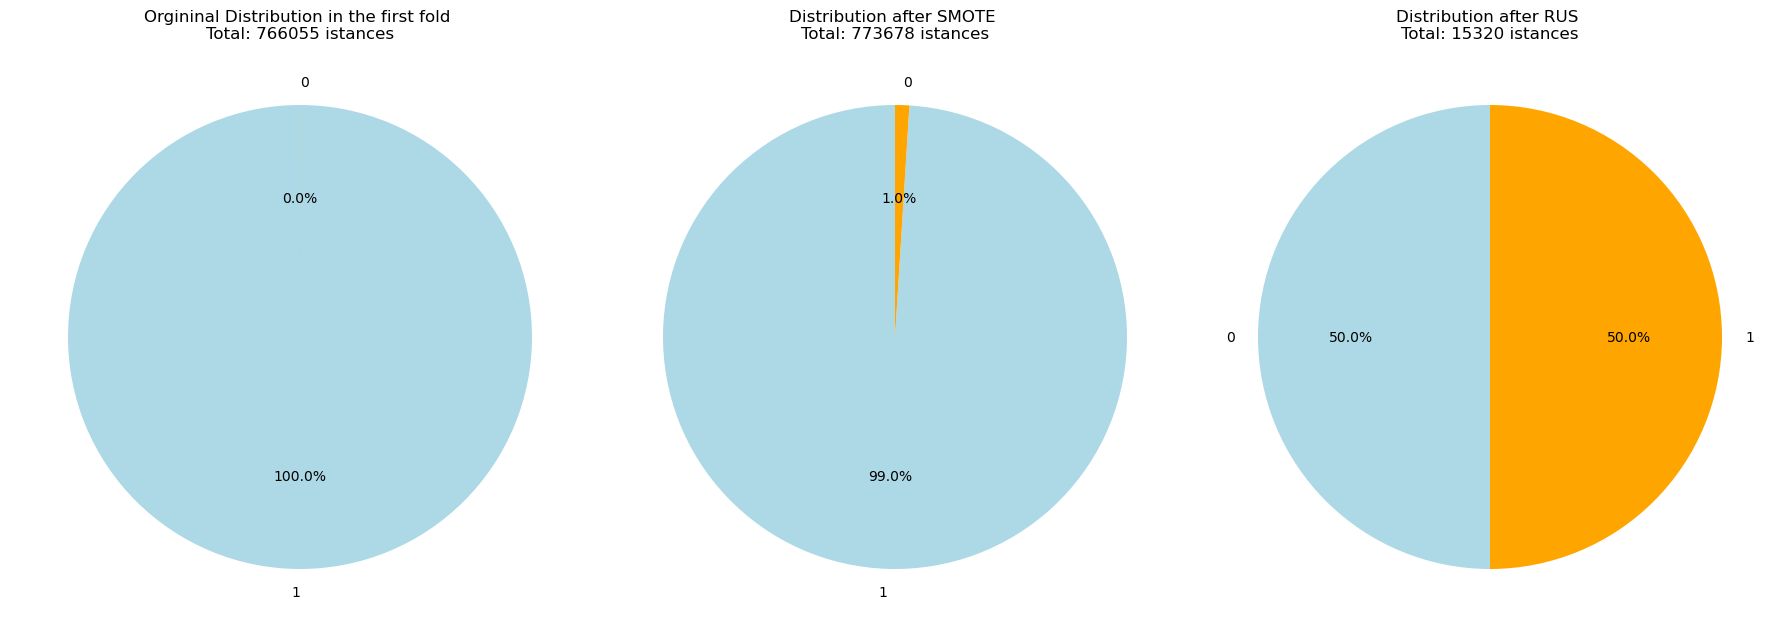

In [9]:
smote = SMOTE(sampling_strategy=0.01, random_state=42)

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

scores = cross_validate(pipeline_no_selection, train_x_num, train_y, cv=skf, scoring=scoring, return_train_score=True)
   

print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}


metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

draw_smote( train_x_num, train_y)

### Smote with sampling = 0.008

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


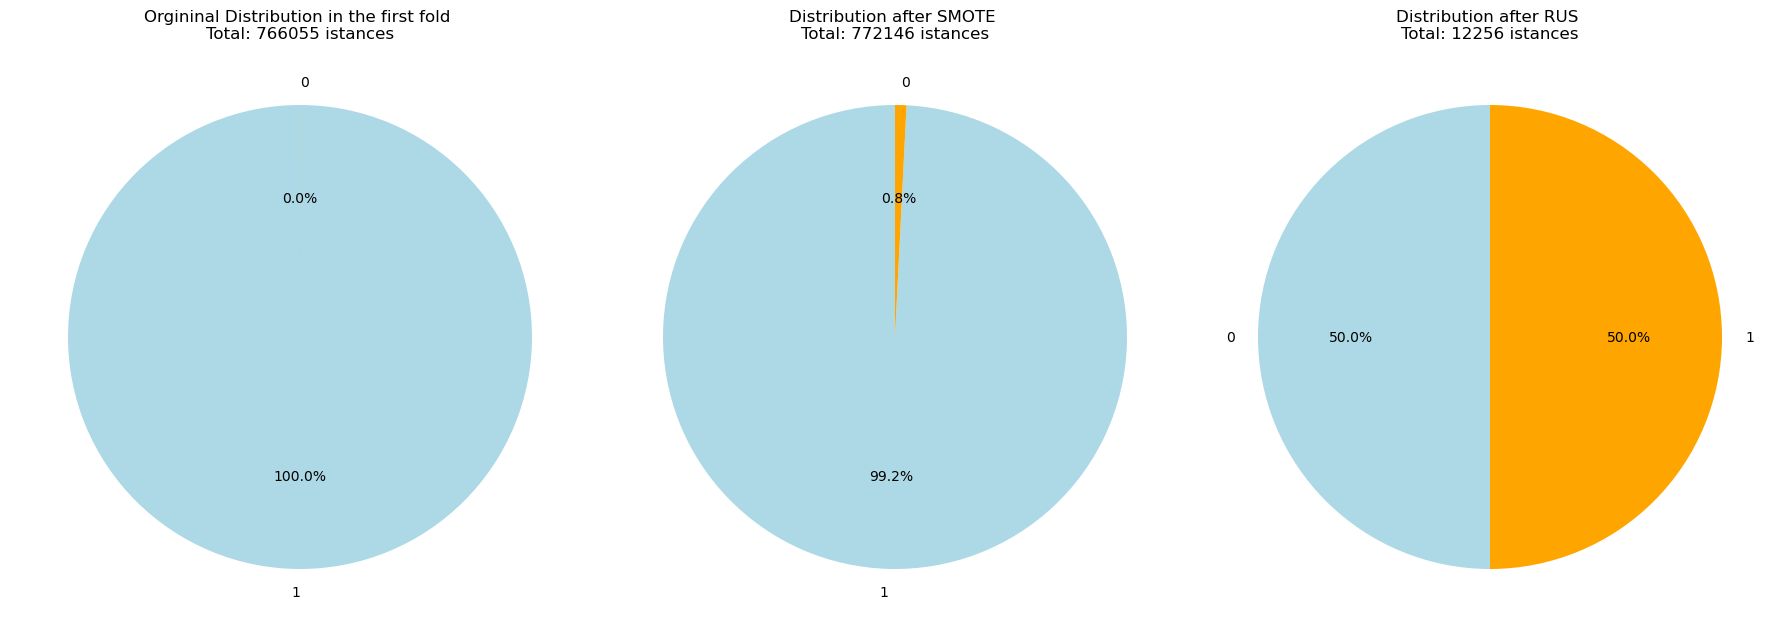

In [10]:
smote = SMOTE(sampling_strategy=0.008, random_state=42)

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

scores = cross_validate(pipeline_no_selection, train_x_num, train_y, cv=skf, scoring=scoring, return_train_score=True)
    
print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}

metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

draw_smote( train_x_num, train_y)

### Smote with sampling = 0.005

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


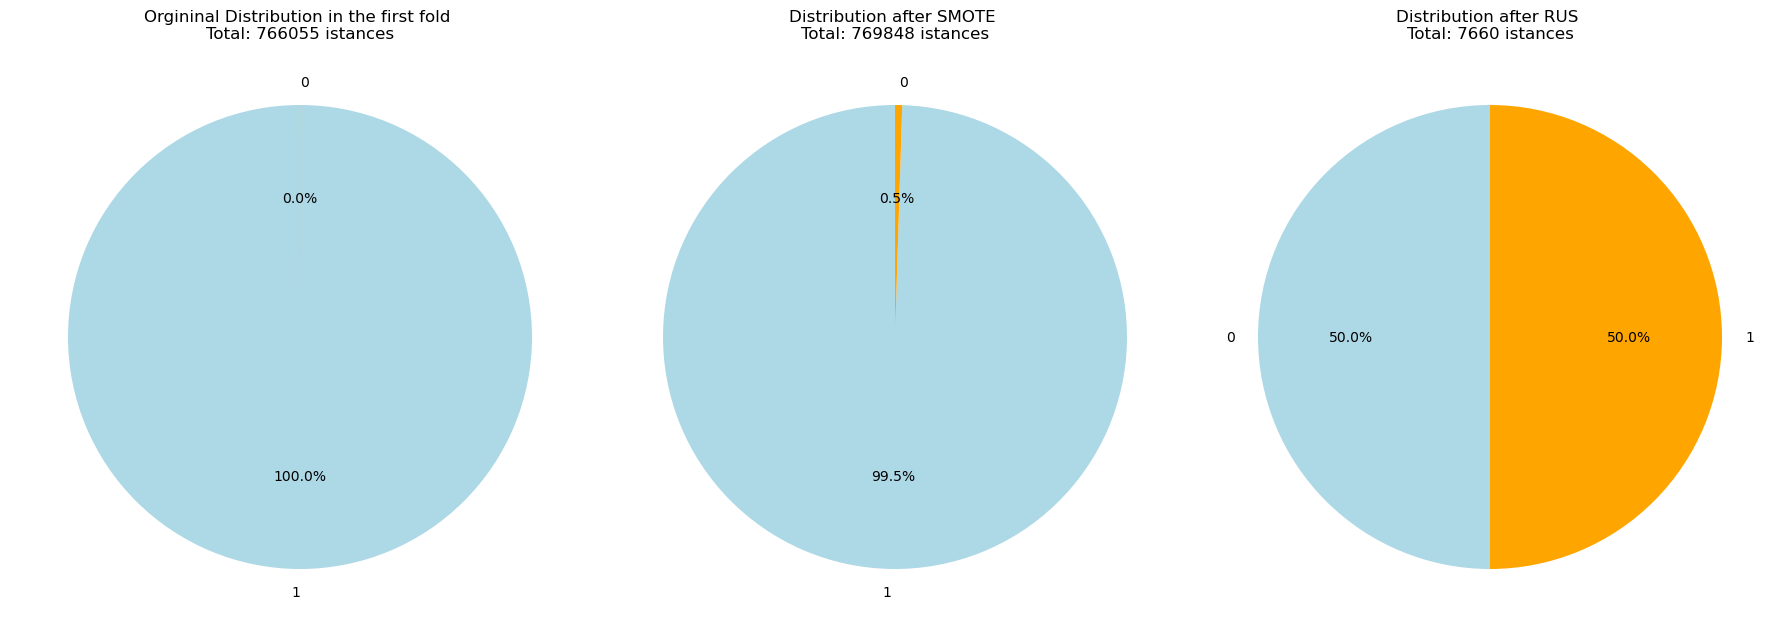

In [11]:
smote = SMOTE(sampling_strategy=0.005, random_state=42)

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

scores = cross_validate(pipeline_no_selection, train_x_num, train_y, cv=skf, scoring=scoring, return_train_score=True)
    
print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}

metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

draw_smote( train_x_num, train_y)

### Smote with sampling = 0.0025

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


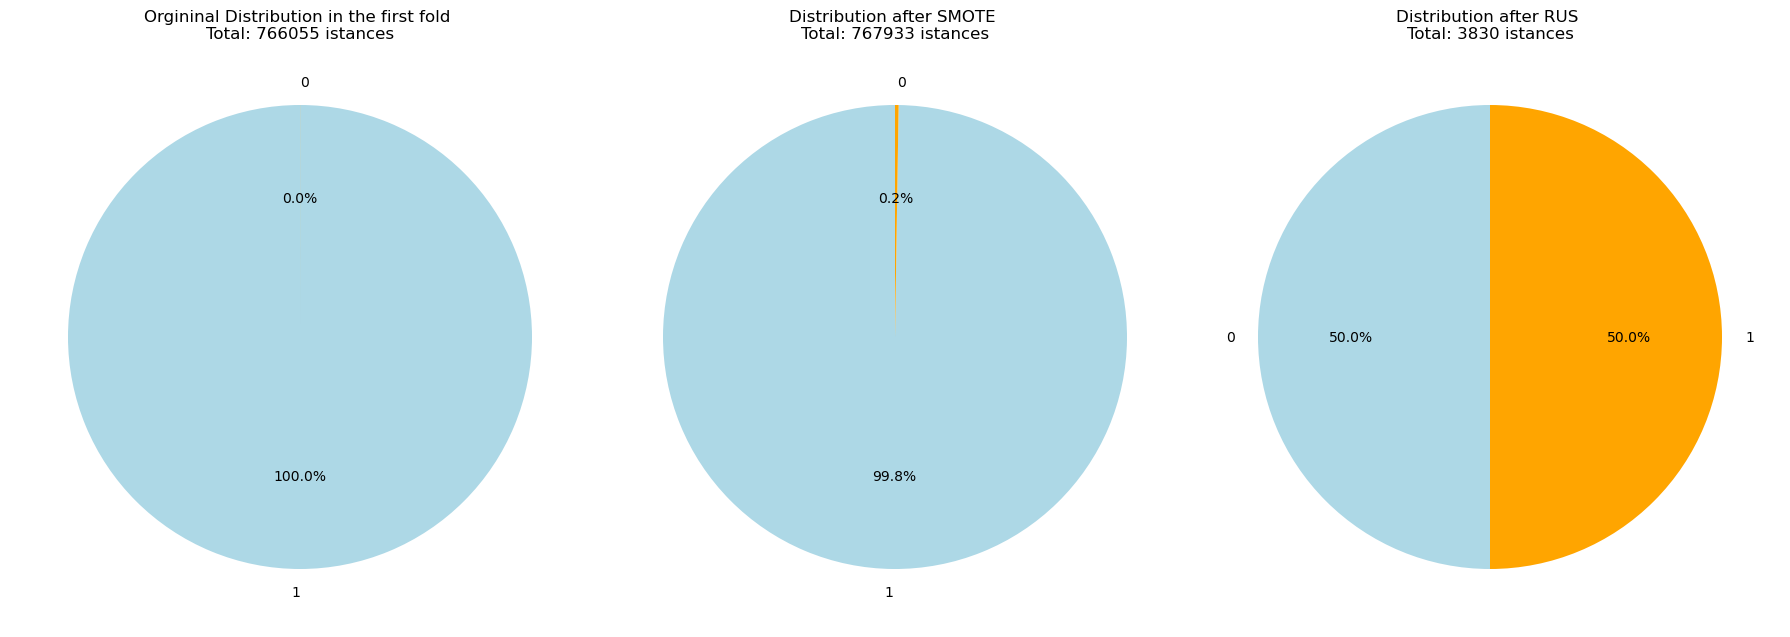

In [12]:
smote = SMOTE(sampling_strategy=0.0025, random_state=42)

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

scores = cross_validate(pipeline_no_selection, train_x_num, train_y, cv=skf, scoring=scoring, return_train_score=True)

print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}

metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

draw_smote( train_x_num, train_y)

### Smote on transformed features 'Hour', 'Weekday', 'Month'

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


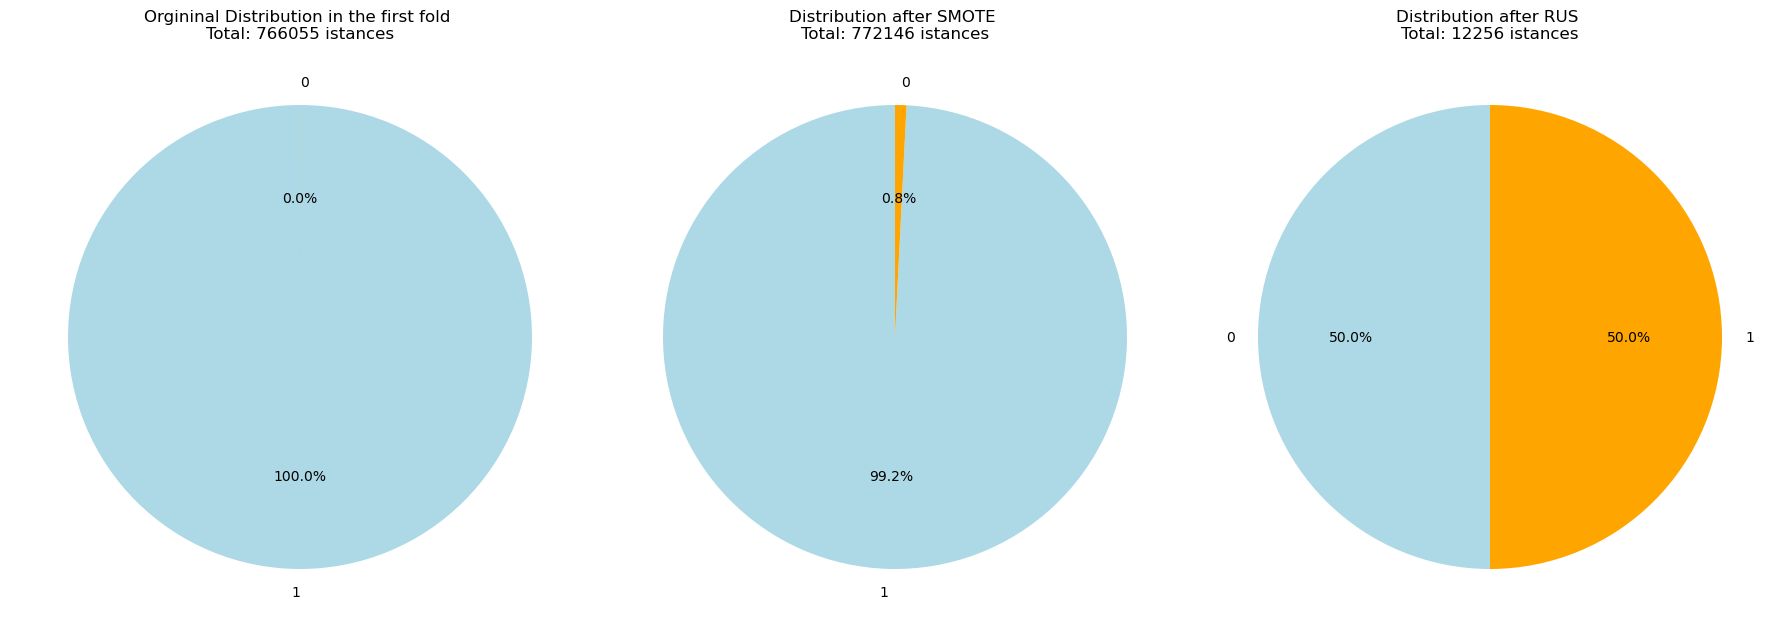

In [13]:
smote = SMOTE(sampling_strategy=0.008, random_state=42)

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']

scores = cross_validate(pipeline_no_selection, train_x, train_y, cv=skf, scoring=scoring, return_train_score=True)
    
print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}

metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

draw_smote( train_x_num, train_y)

## Different rebalancing approach
To evaluate the impact of SMOTE on performance, the analysis also incorporates ADASYN. Adaptive Synthetic Sampling, (ADASYN) is an advanced version of SMOTE that generates new instances non-uniformly, focusing on areas near the decision boundaries of the minority class. This approach is designed to make the classification task more challenging for the Logistic Regressor, potentially highlighting its strengths and weaknesses.

ADASYN -> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html

In [14]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(sampling_strategy=0.005, random_state=42)

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', adasyn),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

scores = cross_validate(pipeline_no_selection, train_x_num, train_y, cv=skf, scoring=scoring, return_train_score=True)

print("Training Scores:")
for metric in scoring:
    print(f"{metric} (train): {scores['train_' + metric]}")

print("\nTest Scores:")
for metric in scoring:
    print(f"{metric} (test): {scores['test_' + metric]}")

metrics_dict = {
    "Train Accuracy": scores['train_accuracy'].mean(),
    "Test Accuracy": scores['test_accuracy'].mean(),
    "Train Precision": scores['train_precision'].mean(),
    "Test Precision": scores['test_precision'].mean(),
    "Train Recall": scores['train_recall'].mean(),
    "Test Recall": scores['test_recall'].mean(),
    "Train F1": scores['train_f1'].mean(),
    "Test F1": scores['test_f1'].mean()
}

metrics_df = pd.DataFrame([metrics_dict])

display(metrics_df)

Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Considerations

In this phase, a rebalancing approach that combines both undersampling and oversampling was implemented. Despite the various techniques applied with different sampling strategies and even the adoption of ADASYN, the classifier maintained perfect performance. This can be attributed to the fact that many features show significantly different values between instances of the two classes, making the classification task relatively straightforward. Even the addition of the features 'Hour','Weekday', and 'Month' that could negatively impact the generation of synthetic istances for 'SMOTE', didn't lead to a degradation of performances, probably because, as demonstrate after the chi-square, those are not related do the target feature. 

The next step involves analyzing how the model generates its predictions by examining the most important features.

For the subsequent phases, the base pipeline will use SMOTE with a sampling strategy of "0.008". This will generate an appropriate number of synthetic samples, ensuring a sufficient amount of data after applying undersampling with RUS

# Step 4: Feature Selection

## Function to evaluate a model

In [7]:
def evaluate_model(train_x_reduced, train_y, pipeline, skf, scoring):
    scores = cross_validate(pipeline, train_x_reduced, train_y, cv=skf, scoring=scoring, return_train_score=True)

    print("\nTraining Scores:")
    for metric in scoring:
        print(f"{metric} (train): {scores['train_' + metric]}")

    print("\nTest Scores:")
    for metric in scoring:
        print(f"{metric} (test): {scores['test_' + metric]}")

    # Media dei punteggi
    metrics_dict = {
        "Train Accuracy": scores['train_accuracy'].mean(),
        "Test Accuracy": scores['test_accuracy'].mean(),
        "Train Precision": scores['train_precision'].mean(),
        "Test Precision": scores['test_precision'].mean(),
        "Train Recall": scores['train_recall'].mean(),
        "Test Recall": scores['test_recall'].mean(),
        "Train F1": scores['train_f1'].mean(),
        "Test F1": scores['test_f1'].mean()
    }

    return pd.DataFrame([metrics_dict])

## Feature Importance with a Decision Tree


Training Scores:
accuracy (train): [0.99965407 0.99966843 0.99966974 0.99966713 0.99966321 0.9996619
 0.99966321 0.99965538 0.99966843 0.99966843]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99965406 0.99966842 0.99966972 0.99966711 0.99966319 0.99966189
 0.99966319 0.99965536 0.99966842 0.99966842]
f1 (train): [0.999827   0.99983418 0.99983483 0.99983353 0.99983157 0.99983092
 0.99983157 0.99982765 0.99983418 0.99983418]

Test Scores:
accuracy (test): [0.99975328 0.99962405 0.9996123  0.9996358  0.99967104 0.99968279
 0.99967104 0.99974153 0.99962405 0.99962405]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [0.99975327 0.99962403 0.99961228 0.99963578 0.99967103 0.99968277
 0.99967103 0.99974152 0.99962403 0.99962403]
f1 (test): [0.99987662 0.99981198 0.9998061  0.99981786 0.99983549 0.99984136
 0.99983549 0.99987074 0.99981198 0.99981198]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999664,0.999664,1.0,1.0,0.999664,0.999664,0.999832,0.999832


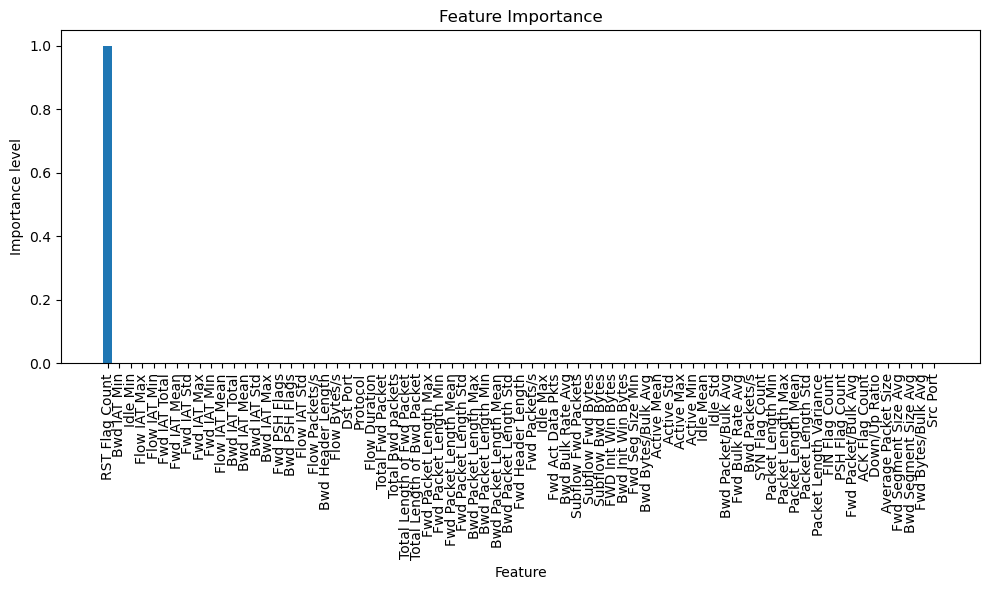

In [8]:
decision_tree = DecisionTreeClassifier(random_state=42)
smote = SMOTE(sampling_strategy=0.008, random_state=42)
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)

pipeline_tree = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('classifier', decision_tree)
])

pipeline_tree.fit(train_x_num, train_y)

tree_model = pipeline_tree.named_steps['classifier']
feature_importances = tree_model.feature_importances_

sorted_indices = np.argsort(feature_importances)[::-1]


plt.figure(figsize=(10, 6))
plt.bar(range(train_x_num.shape[1]), feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_num.shape[1]), train_x_num.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance level")
plt.tight_layout()
plt.show

#TRAINING THE REGRESSOR WITH THE BEST FEATURES

important_features = train_x_num.columns[feature_importances > 0.02]
train_x_reduced = train_x_num[important_features]

scoring = ['accuracy','precision','recall','f1']

metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)


## Removing the most important feature

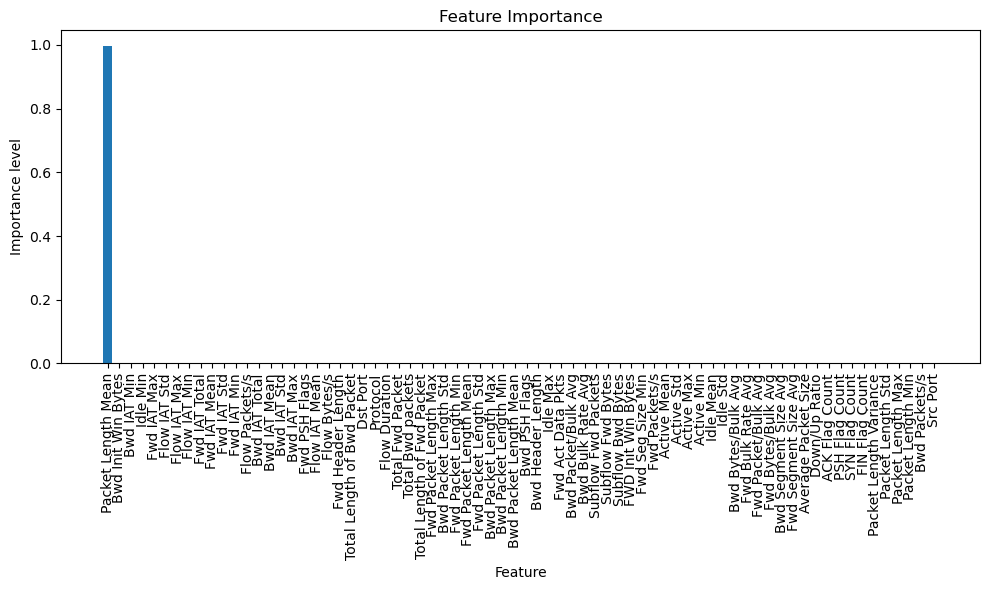


Training Scores:
accuracy (train): [0.99877032 0.99878468 0.99879513 0.99878338 0.99880165 0.99875988
 0.9987886  0.99875466 0.99882515 0.99880035]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99877026 0.99878462 0.99879507 0.99878332 0.9988016  0.99875982
 0.99878854 0.9987546  0.99882509 0.99880029]
f1 (train): [0.99938475 0.99939194 0.99939717 0.99939129 0.99940044 0.99937953
 0.9993939  0.99937691 0.9994122  0.99939979]

Test Scores:
accuracy (test): [0.9989309  0.99880166 0.99870768 0.9988134  0.99864892 0.99902487
 0.9987664  0.99907187 0.99843744 0.99866067]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [0.99893085 0.99880161 0.9987076  0.99881334 0.99864886 0.99902483
 0.99876635 0.99907182 0.99843737 0.9986606 ]
f1 (test): [0.99946514 0.99940044 0.99935338 0.99940632 0.99932397 0.99951218
 0.99938279 0.9995357  0.99921807 0.99932985]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.998786,0.998786,1.0,1.0,0.998786,0.998786,0.999393,0.999393


In [17]:
train_x_pruned= train_x_num.drop('RST Flag Count', axis=1)

pipeline_tree.fit(train_x_pruned, train_y)

tree_model = pipeline_tree.named_steps['classifier']
feature_importances = tree_model.feature_importances_

sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_pruned.shape[1]), feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_pruned.shape[1]), train_x_pruned.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance level")
plt.tight_layout()
plt.show()

#TRAINING THE REGRESSOR WITH THE BEST FEATURES

important_features = train_x_pruned.columns[feature_importances > 0.02]
train_x_reduced = train_x_pruned[important_features]

scoring = ['accuracy','precision','recall','f1']

metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)


## Removing characteristics features

As expected, there are many features that can be used in isolation to discriminate between classes. To understand the impact of this, the most important features will be removed, and the performance of the Linear Regressor with the new subset of features will be evaluated.

### Checks on the possibility to use t test

In [18]:
from scipy.stats import shapiro

benign_features = train_x_num[train_y == 0]
hulk_features = train_x_num[train_y == 1]


shapiro_benign = shapiro(benign_features)
shapiro_hulk = shapiro(hulk_features)


print("Test for normal distribution (Shapiro-Wilk):")
print(f"Benign: p-value = {shapiro_benign.pvalue}")
print(f"Hulk: p-value = {shapiro_hulk.pvalue}")

if shapiro_benign.pvalue > 0.05 and shapiro_hulk.pvalue > 0.05:
    print("Both Normally distributed.")
else:
    print("At least one is not normally distributed")

Test for normal distribution (Shapiro-Wilk):
Benign: p-value = 6.137045391937791e-78
Hulk: p-value = 1.2306408781223335e-212
At least one is not normally distributed


C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 62132636.
  res = hypotest_fun_out(*samples, **kwds)


### Next step
One approach to conducting the analysis was to remove features based on their significant difference between instances of different classes, calculated using a "t-test." However, this approach was not feasible because the two classes do not follow a normal distribution, as indicated by the Shapiro-Wilk test. Therefore, the chosen alternative is to assess feature importance using a decision tree model. In this method, we iteratively remove the most important features and observe how the model's performance is affected.
Shapiro-Wilk test -> https://www.agnesevardanega.eu/wiki/r/test_statistici/shapiro-test

## Function to delete important features

In [19]:
def eliminate_important_features(pipeline, train_x, train_y, num_features_to_keep):
    train_x_copy = train_x.copy()
    eliminated_features = []
    pipeline.fit(train_x_copy, train_y)

    while train_x_copy.shape[1] > num_features_to_keep:
        tree_model = pipeline.named_steps['classifier']
        feature_importances = tree_model.feature_importances_
        most_important_index = np.argmax(feature_importances)

        most_important_feature = train_x_copy.columns[most_important_index]
        importance_value = feature_importances[most_important_index]
        eliminated_features.append((most_important_feature, importance_value))

       
        train_x_copy = train_x_copy.drop(most_important_feature, axis=1)

        
        pipeline.fit(train_x_copy, train_y)


    tree_model = pipeline.named_steps['classifier']
    final_feature_importances = tree_model.feature_importances_

    return train_x_copy, final_feature_importances, eliminated_features

### Keeping 10 features

[('RST Flag Count', 0.9982391782831987),
 ('Packet Length Mean', 0.9961888009381413),
 ('Subflow Bwd Bytes', 0.9961888009381413),
 ('Packet Length Std', 0.9961888009381413),
 ('Packet Length Variance', 0.9961888009381413),
 ('Total Length of Bwd Packet', 0.9961888009381413),
 ('Bwd Packet Length Mean', 0.9961888009381413),
 ('Bwd Packet Length Max', 0.9961888009381413),
 ('Bwd Packet Length Std', 0.9961888009381413),
 ('Packet Length Max', 0.9961888009381413),
 ('Average Packet Size', 0.9961888009381413),
 ('Bwd Segment Size Avg', 0.9961888009381413),
 ('SYN Flag Count', 0.8840619811842834),
 ('FWD Init Win Bytes', 0.8840619811842834),
 ('FIN Flag Count', 0.8729032569992811),
 ('Subflow Fwd Packets', 0.8430098795506834),
 ('Fwd Seg Size Min', 0.8395220659989227),
 ('Src Port', 0.822049772544822),
 ('Bwd Init Win Bytes', 0.8151987574923888),
 ('Down/Up Ratio', 0.7985503917580072),
 ('Fwd Packet Length Std', 0.7849605465330534),
 ('Flow Bytes/s', 0.7814284924331024),
 ('Dst Port', 0.7551

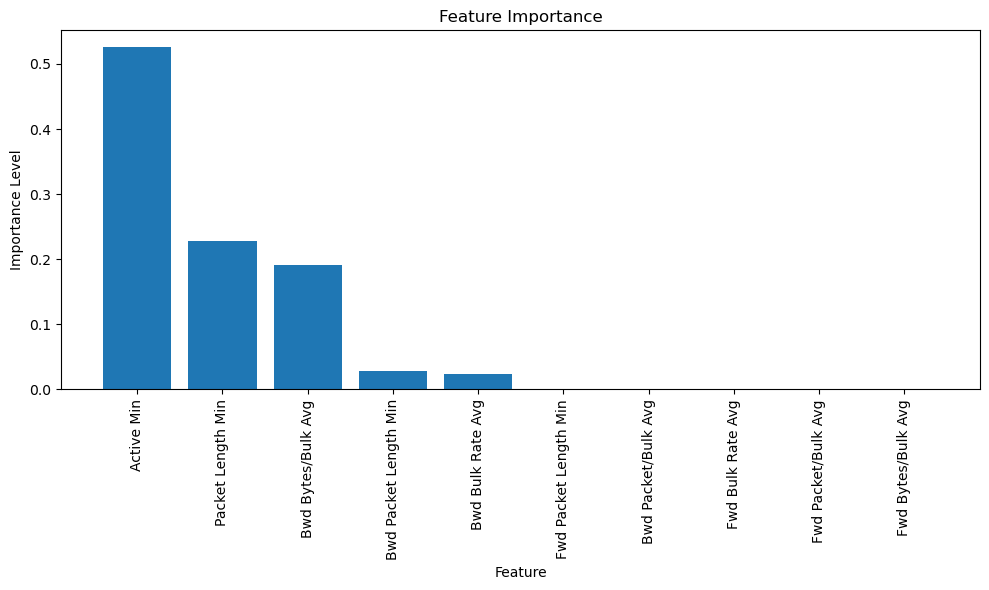


Training Scores:
accuracy (train): [0.99333077 0.99339081 0.99363492 0.99376025 0.9937968  0.9934104
 0.99347959 0.99329945 0.99337777 0.99354094]
precision (train): [0.99998029 0.9999816  0.99998161 0.9999803  0.9999803  0.9999816
 0.99998029 0.99998029 0.99997897 0.99998161]
recall (train): [0.99335003 0.99340877 0.9936529  0.99377953 0.99381608 0.99342836
 0.99349886 0.9933187  0.99339834 0.99355891]
f1 (train): [0.99665413 0.99668435 0.99680721 0.99687027 0.99688866 0.99669421
 0.99672904 0.99663836 0.99667779 0.99675991]

Test Scores:
accuracy (test): [0.99345614 0.99379685 0.99313894 0.99384377 0.99411398 0.99313886
 0.99336208 0.99353831 0.9931976  0.99347956]
precision (test): [0.99998817 0.99997636 0.99995268 0.99997636 0.99997636 0.99997634
 0.99998817 0.99998817 1.         0.99997635]
recall (test): [0.99346758 0.99382005 0.99318553 0.99386698 0.99413721 0.99316203
 0.99337352 0.99354975 0.99319728 0.99350276]
f1 (test): [0.99671721 0.9968887  0.99655762 0.99691231 0.997048

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.993502,0.993507,0.999981,0.99998,0.993521,0.993526,0.99674,0.996743


In [20]:
train_x_reduced, final_feature_importances, deleted_features = eliminate_important_features(pipeline_tree, train_x_num, train_y,10)

display(deleted_features)

selected_features= train_x_reduced


sorted_indices = np.argsort(final_feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_reduced.shape[1]), final_feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_reduced.shape[1]), train_x_reduced.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Level")
plt.tight_layout()
plt.show()

# SCORING OF THE LINEAR REGRESSOR WITH THE UPDATED FEATURES

scoring = ['accuracy','precision','recall','f1']
metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)

### Keeping 5 features

[('RST Flag Count', 0.9982391782831987),
 ('Packet Length Mean', 0.9961888009381413),
 ('Subflow Bwd Bytes', 0.9961888009381413),
 ('Packet Length Std', 0.9961888009381413),
 ('Packet Length Variance', 0.9961888009381413),
 ('Total Length of Bwd Packet', 0.9961888009381413),
 ('Bwd Packet Length Mean', 0.9961888009381413),
 ('Bwd Packet Length Max', 0.9961888009381413),
 ('Bwd Packet Length Std', 0.9961888009381413),
 ('Packet Length Max', 0.9961888009381413),
 ('Average Packet Size', 0.9961888009381413),
 ('Bwd Segment Size Avg', 0.9961888009381413),
 ('SYN Flag Count', 0.8840619811842834),
 ('FWD Init Win Bytes', 0.8840619811842834),
 ('FIN Flag Count', 0.8729032569992811),
 ('Subflow Fwd Packets', 0.8430098795506834),
 ('Fwd Seg Size Min', 0.8395220659989227),
 ('Src Port', 0.822049772544822),
 ('Bwd Init Win Bytes', 0.8151987574923888),
 ('Down/Up Ratio', 0.7985503917580072),
 ('Fwd Packet Length Std', 0.7849605465330534),
 ('Flow Bytes/s', 0.7814284924331024),
 ('Dst Port', 0.7551

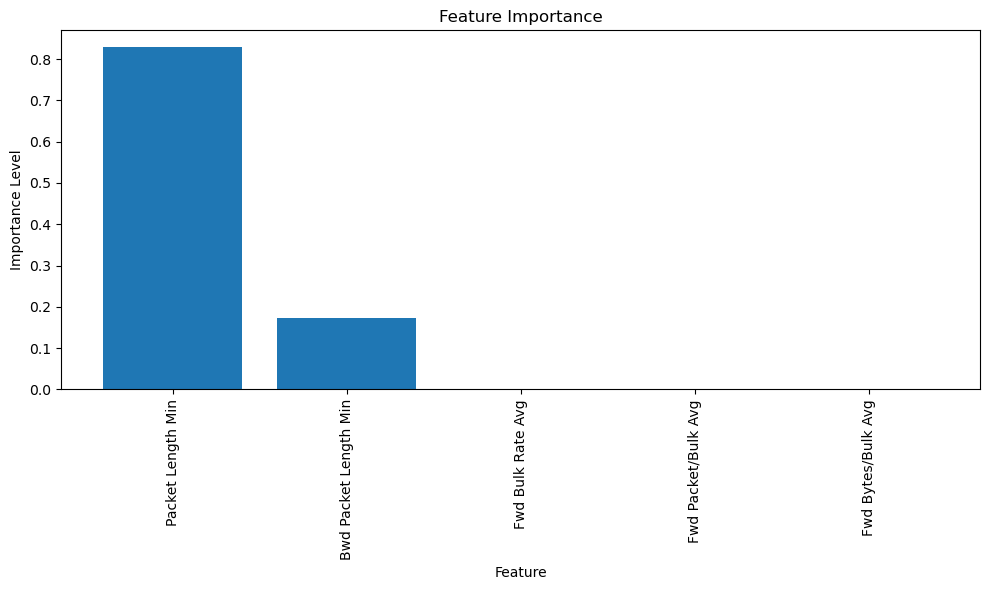


Training Scores:
accuracy (train): [0.99996737 0.99996737 0.99996867 0.99996606 0.99996737 0.99996737
 0.99996606 0.99996737 0.99996475 0.99996867]
precision (train): [0.99996736 0.99996736 0.99996867 0.99996606 0.99996736 0.99996736
 0.99996606 0.99996736 0.99996475 0.99996867]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [0.99998368 0.99998368 0.99998433 0.99998303 0.99998368 0.99998368
 0.99998303 0.99998368 0.99998238 0.99998433]

Test Scores:
accuracy (test): [0.99996475 0.99996475 0.99995301 0.9999765  0.99996475 0.99996475
 0.9999765  0.99996475 0.99998825 0.99995301]
precision (test): [0.99996475 0.99996475 0.99995301 0.9999765  0.99996475 0.99996475
 0.9999765  0.99996475 0.99998825 0.99995301]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [0.99998238 0.99998238 0.9999765  0.99998825 0.99998238 0.99998238
 0.99998825 0.99998238 0.99999413 0.9999765 ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999967,0.999967,0.999967,0.999967,1.0,1.0,0.999984,0.999984


In [21]:
train_x_reduced, final_feature_importances,deleted_features = eliminate_important_features(pipeline_tree, train_x_num, train_y,5)

display(deleted_features)

sorted_indices = np.argsort(final_feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_reduced.shape[1]), final_feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_reduced.shape[1]), train_x_reduced.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Level")
plt.tight_layout()
plt.show()

# SCORING OF THE LINEAR REGRESSOR WITH THE UPDATED FEATURES

scoring = ['accuracy','precision','recall','f1']
metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)

### Keeping 1 feature

[('RST Flag Count', 0.9982391782831987),
 ('Packet Length Mean', 0.9961888009381413),
 ('Subflow Bwd Bytes', 0.9961888009381413),
 ('Packet Length Std', 0.9961888009381413),
 ('Packet Length Variance', 0.9961888009381413),
 ('Total Length of Bwd Packet', 0.9961888009381413),
 ('Bwd Packet Length Mean', 0.9961888009381413),
 ('Bwd Packet Length Max', 0.9961888009381413),
 ('Bwd Packet Length Std', 0.9961888009381413),
 ('Packet Length Max', 0.9961888009381413),
 ('Average Packet Size', 0.9961888009381413),
 ('Bwd Segment Size Avg', 0.9961888009381413),
 ('SYN Flag Count', 0.8840619811842834),
 ('FWD Init Win Bytes', 0.8840619811842834),
 ('FIN Flag Count', 0.8729032569992811),
 ('Subflow Fwd Packets', 0.8430098795506834),
 ('Fwd Seg Size Min', 0.8395220659989227),
 ('Src Port', 0.822049772544822),
 ('Bwd Init Win Bytes', 0.8151987574923888),
 ('Down/Up Ratio', 0.7985503917580072),
 ('Fwd Packet Length Std', 0.7849605465330534),
 ('Flow Bytes/s', 0.7814284924331024),
 ('Dst Port', 0.7551

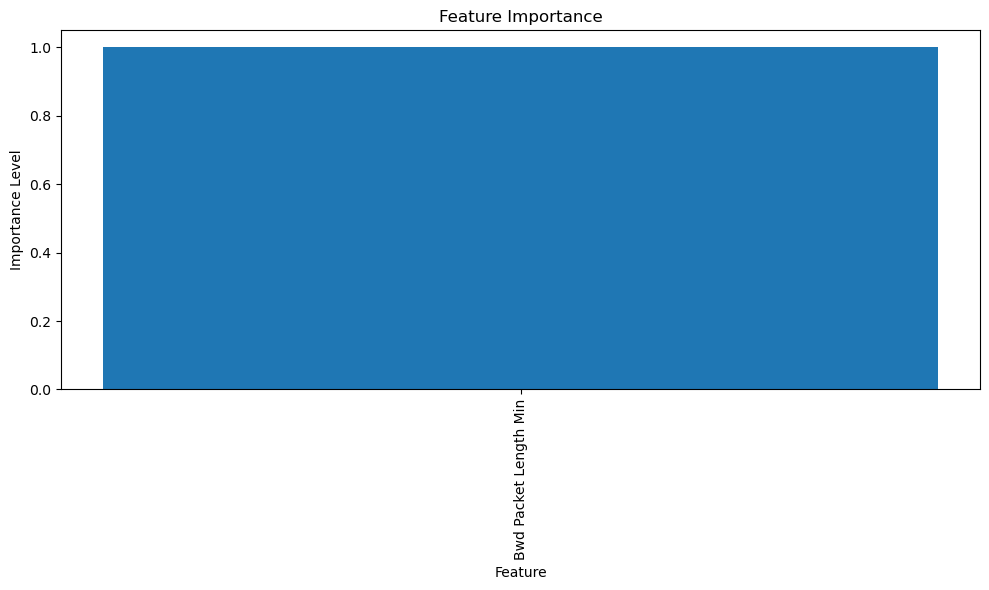


Training Scores:
accuracy (train): [0.99995431 0.99995431 0.99995562 0.99995431 0.99995431 0.99995431
 0.99995431 0.99995301 0.99995301 0.99995431]
precision (train): [0.99995431 0.99995431 0.99995562 0.99995431 0.99995431 0.99995431
 0.99995431 0.99995301 0.99995301 0.99995431]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [0.99997716 0.99997716 0.99997781 0.99997716 0.99997716 0.99997716
 0.99997716 0.9999765  0.9999765  0.99997716]

Test Scores:
accuracy (test): [0.99995301 0.99995301 0.99994126 0.99995301 0.99995301 0.99995301
 0.99995301 0.99996475 0.99996475 0.99995301]
precision (test): [0.99995301 0.99995301 0.99994126 0.99995301 0.99995301 0.99995301
 0.99995301 0.99996475 0.99996475 0.99995301]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [0.9999765  0.9999765  0.99997063 0.9999765  0.9999765  0.9999765
 0.9999765  0.99998238 0.99998238 0.9999765 ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999954,0.999954,0.999954,0.999954,1.0,1.0,0.999977,0.999977


In [22]:
train_x_reduced, final_feature_importances, deleted_features = eliminate_important_features(pipeline_tree, train_x_num, train_y,1)

display(deleted_features)
sorted_indices = np.argsort(final_feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_reduced.shape[1]), final_feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_reduced.shape[1]), train_x_reduced.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Level")
plt.tight_layout()
plt.show()

# SCORING OF THE LINEAR REGRESSOR WITH THE UPDATED FEATURES

scoring = ['accuracy','precision','recall','f1']
metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)

## Keeping ten features with transformed features 'Hour', 'Weekday, 'Month'

[('RST Flag Count', 0.9982391782831987),
 ('Bwd Segment Size Avg', 0.9961888009381413),
 ('Packet Length Mean', 0.9961888009381413),
 ('Subflow Bwd Bytes', 0.9961888009381413),
 ('Packet Length Std', 0.9961888009381413),
 ('Bwd Packet Length Mean', 0.9961888009381413),
 ('Bwd Packet Length Std', 0.9961888009381413),
 ('Bwd Packet Length Max', 0.9961888009381413),
 ('Packet Length Max', 0.9961888009381413),
 ('Average Packet Size', 0.9961888009381413),
 ('Packet Length Variance', 0.9961888009381413),
 ('Total Length of Bwd Packet', 0.9961888009381413),
 ('SYN Flag Count', 0.8840619811842834),
 ('FWD Init Win Bytes', 0.8840619811842834),
 ('FIN Flag Count', 0.8729032569992811),
 ('Subflow Fwd Packets', 0.8430098795506834),
 ('Fwd Seg Size Min', 0.8395220659989225),
 ('Src Port', 0.822049772544822),
 ('Bwd Init Win Bytes', 0.8151987574923887),
 ('Down/Up Ratio', 0.7976365685501615),
 ('Fwd Packet Length Std', 0.7849605465330534),
 ('Flow Bytes/s', 0.7814284924331024),
 ('Dst Port', 0.7551

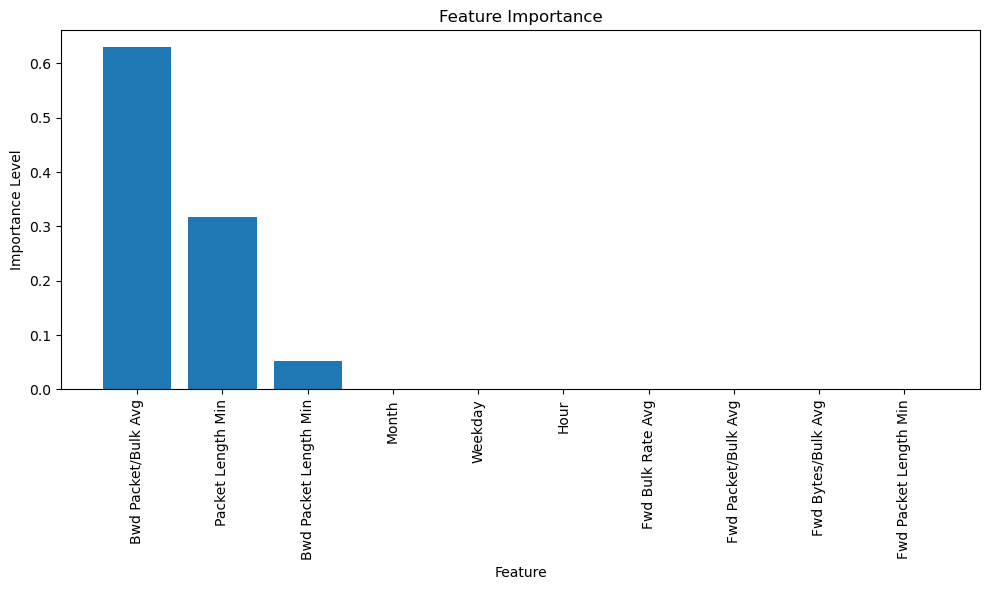


Training Scores:
accuracy (train): [0.31307282 0.31378165 0.31354668 0.31373033 0.31300714 0.31333871
 0.31352408 0.31338962 0.31362459 0.31358804]
precision (train): [0.99999583 0.99999584 1.         0.99999584 0.99999583 0.99999583
 0.99999584 0.99999583 0.99999584 0.99999584]
recall (train): [0.31304095 0.31374981 0.31351442 0.31369849 0.31297527 0.31330685
 0.31349222 0.31335776 0.31359274 0.31355619]
f1 (train): [0.47681778 0.47763964 0.4773673  0.47758017 0.47674158 0.47712618
 0.4773411  0.47718521 0.47745762 0.47741525]

Test Scores:
accuracy (test): [0.31694824 0.31056886 0.31268357 0.3110307  0.31753939 0.31455526
 0.31288697 0.31409707 0.31198233 0.31231129]
precision (test): [1.         1.         0.99996242 1.         1.         1.
 1.         1.         1.         1.        ]
recall (test): [0.31691614 0.31053646 0.31265494 0.31099832 0.31750731 0.31452305
 0.31285468 0.31406483 0.31195    0.31227897]
f1 (test): [0.48130041 0.47390739 0.47636608 0.47444503 0.48198186 0.4

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.31346,0.31346,0.999996,0.999996,0.313428,0.313428,0.477267,0.477263


In [23]:
train_x_reduced, final_feature_importances, deleted_features = eliminate_important_features(pipeline_tree, train_x, train_y,10)

display(deleted_features)
sorted_indices = np.argsort(final_feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_reduced.shape[1]), final_feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_reduced.shape[1]), train_x_reduced.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Level")
plt.tight_layout()
plt.show()

# SCORING OF THE LINEAR REGRESSOR WITH THE UPDATED FEATURES

scoring = ['accuracy','precision','recall','f1']
metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)

## Keeping five features with transformed features 'Hour', 'Weekday, 'Month'

[('RST Flag Count', 0.9982391782831987),
 ('Bwd Segment Size Avg', 0.9961888009381413),
 ('Packet Length Mean', 0.9961888009381413),
 ('Subflow Bwd Bytes', 0.9961888009381413),
 ('Packet Length Std', 0.9961888009381413),
 ('Bwd Packet Length Mean', 0.9961888009381413),
 ('Bwd Packet Length Std', 0.9961888009381413),
 ('Bwd Packet Length Max', 0.9961888009381413),
 ('Packet Length Max', 0.9961888009381413),
 ('Average Packet Size', 0.9961888009381413),
 ('Packet Length Variance', 0.9961888009381413),
 ('Total Length of Bwd Packet', 0.9961888009381413),
 ('SYN Flag Count', 0.8840619811842834),
 ('FWD Init Win Bytes', 0.8840619811842834),
 ('FIN Flag Count', 0.8729032569992811),
 ('Subflow Fwd Packets', 0.8430098795506834),
 ('Fwd Seg Size Min', 0.8395220659989225),
 ('Src Port', 0.822049772544822),
 ('Bwd Init Win Bytes', 0.8151987574923887),
 ('Down/Up Ratio', 0.7976365685501615),
 ('Fwd Packet Length Std', 0.7849605465330534),
 ('Flow Bytes/s', 0.7814284924331024),
 ('Dst Port', 0.7551

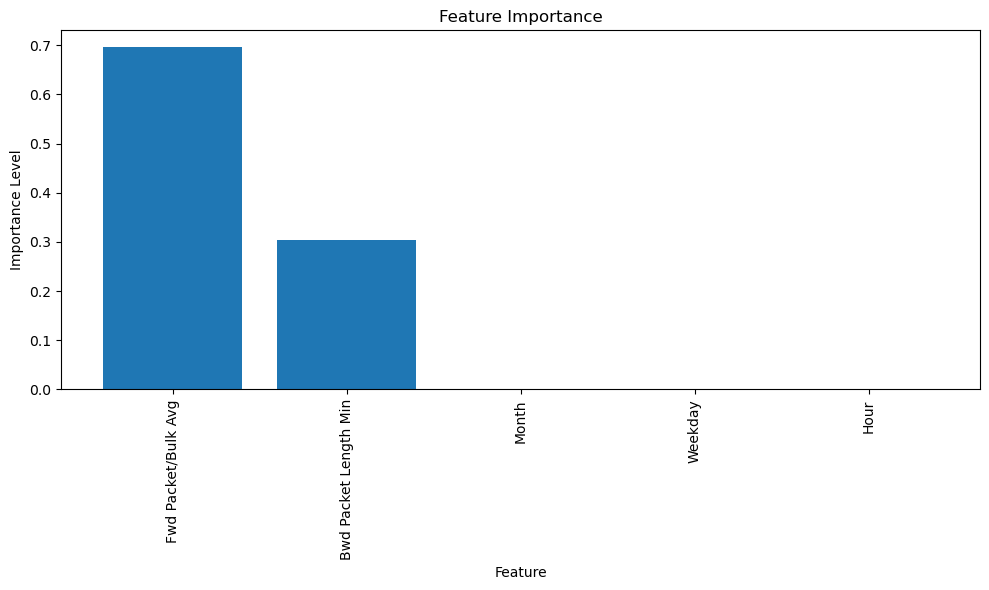


Training Scores:
accuracy (train): [0.99995953 0.99995953 0.99996214 0.99995953 0.99996084 0.99996084
 0.99995953 0.99995953 0.99995823 0.99996084]
precision (train): [0.99995953 0.99995953 0.99996214 0.99995953 0.99996084 0.99996084
 0.99995953 0.99995953 0.99995823 0.99996084]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [0.99997977 0.99997977 0.99998107 0.99997977 0.99998042 0.99998042
 0.99997977 0.99997977 0.99997911 0.99998042]

Test Scores:
accuracy (test): [0.99996475 0.99996475 0.99994126 0.99996475 0.99995301 0.99995301
 0.99996475 0.99996475 0.9999765  0.99995301]
precision (test): [0.99996475 0.99996475 0.99994126 0.99996475 0.99995301 0.99995301
 0.99996475 0.99996475 0.9999765  0.99995301]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [0.99998238 0.99998238 0.99997063 0.99998238 0.9999765  0.9999765
 0.99998238 0.99998238 0.99998825 0.9999765 ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.99996,0.99996,0.99996,0.99996,1.0,1.0,0.99998,0.99998


In [24]:
train_x_reduced, final_feature_importances, deleted_features = eliminate_important_features(pipeline_tree, train_x, train_y,5)

display(deleted_features)
sorted_indices = np.argsort(final_feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_reduced.shape[1]), final_feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_reduced.shape[1]), train_x_reduced.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Level")
plt.tight_layout()
plt.show()

# SCORING OF THE LINEAR REGRESSOR WITH THE UPDATED FEATURES

scoring = ['accuracy','precision','recall','f1']
metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)

## Keeping one feature with transformed features 'Hour', 'Weekday, 'Month'

[('RST Flag Count', 0.9982391782831987),
 ('Bwd Segment Size Avg', 0.9961888009381413),
 ('Packet Length Mean', 0.9961888009381413),
 ('Subflow Bwd Bytes', 0.9961888009381413),
 ('Packet Length Std', 0.9961888009381413),
 ('Bwd Packet Length Mean', 0.9961888009381413),
 ('Bwd Packet Length Std', 0.9961888009381413),
 ('Bwd Packet Length Max', 0.9961888009381413),
 ('Packet Length Max', 0.9961888009381413),
 ('Average Packet Size', 0.9961888009381413),
 ('Packet Length Variance', 0.9961888009381413),
 ('Total Length of Bwd Packet', 0.9961888009381413),
 ('SYN Flag Count', 0.8840619811842834),
 ('FWD Init Win Bytes', 0.8840619811842834),
 ('FIN Flag Count', 0.8729032569992811),
 ('Subflow Fwd Packets', 0.8430098795506834),
 ('Fwd Seg Size Min', 0.8395220659989225),
 ('Src Port', 0.822049772544822),
 ('Bwd Init Win Bytes', 0.8151987574923887),
 ('Down/Up Ratio', 0.7976365685501615),
 ('Fwd Packet Length Std', 0.7849605465330534),
 ('Flow Bytes/s', 0.7814284924331024),
 ('Dst Port', 0.7551

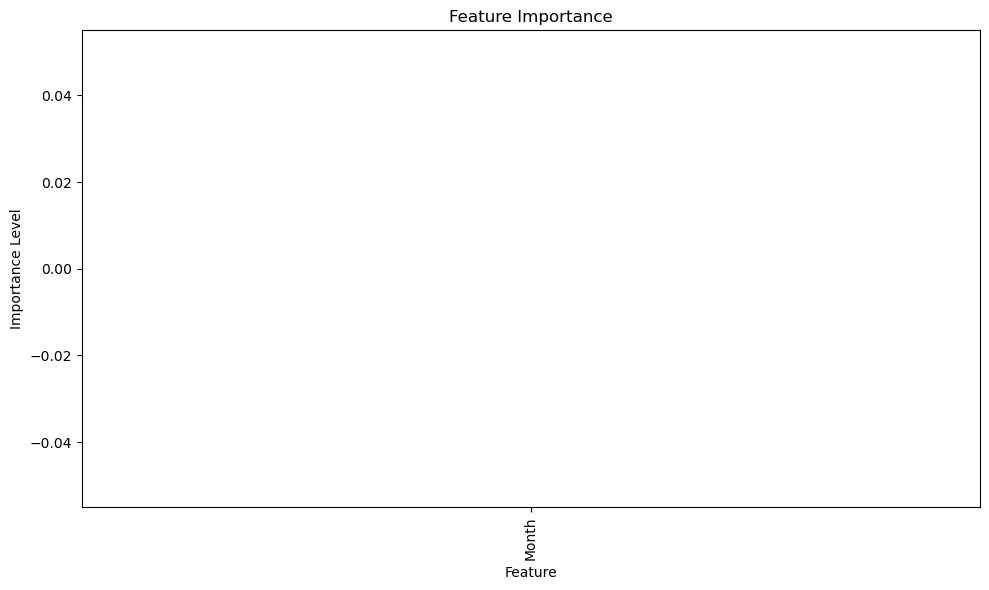

C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\fabbr\miniconda3\envs\AiFinal\lib\site-packages\sklearn\metrics\_cl


Training Scores:
accuracy (train): [4.82994041e-05 4.82994041e-05 4.69940148e-05 4.82993410e-05
 4.82993410e-05 4.82993410e-05 4.82993410e-05 4.82993410e-05
 4.82993410e-05 4.82993410e-05]
precision (train): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
recall (train): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
f1 (train): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Test Scores:
accuracy (test): [4.69935854e-05 4.69935854e-05 5.87419817e-05 4.69941375e-05
 4.69941375e-05 4.69941375e-05 4.69941375e-05 4.69941375e-05
 4.69941375e-05 4.69941375e-05]
precision (test): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
recall (test): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
f1 (test): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.000048,0.000048,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
train_x_reduced, final_feature_importances, deleted_features = eliminate_important_features(pipeline_tree, train_x, train_y,1)

display(deleted_features)
sorted_indices = np.argsort(final_feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(train_x_reduced.shape[1]), final_feature_importances[sorted_indices], align="center")
plt.xticks(range(train_x_reduced.shape[1]), train_x_reduced.columns[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance Level")
plt.tight_layout()
plt.show()

# SCORING OF THE LINEAR REGRESSOR WITH THE UPDATED FEATURES

scoring = ['accuracy','precision','recall','f1']
metrics_df = evaluate_model(train_x_reduced, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df)

## **The errors were not deleted because they are significant for the subsequent considerations**

# Considerations

After the analysis on the features importance, it's possible to conclude that this classification problem is simple, because there is a clear distinction in most of the features from the 'Benign' istances to the 'Hulk' instances and the model is able to use just one features to perform the classification task. 

The most important feature for the model is "RST Flag Count", that can be significant for the case because, during an Hulk attack, the server overwhelmed by the attack can try to forcibly close or reset connections.

The scores of the Linear Regressor state that the model is not in overfittng, because the training score and the test score are equal, and that the model is able to classify all the unseen istances even with only just one feature left.

In the latest analysis, the transformed features 'Hour,' 'Weekday,' and 'Month,' derived from the categorical field 'Timestamp,' were added to the dataset. This addition resulted in a decline in the model's performance because, as previously stated, these features are not significant for classification. Furthermore, the enforced removal of the most predictive features caused the remaining features, including the newly added ones, to be less informative compared to the previous scenario. The extent of this is the fact that in the latest scenario a lot of warnings arise because the only remaining feature was 'Month' and the model was not able to classify with just that feature.  
It’s notable the fact that the performances with only five remaining features are comparable with the previous case, stating that even if those are the least important ones, they still carry enough information to allow the model to maintain high accuracy and effectively distinguish between classes. This highlights that the selection process may exclude these features even if they are more performant than others that were chosen earlier.


# Feature Selection with Mutual Information

In [12]:
from sklearn.feature_selection import mutual_info_classif

def select_top_k_features_mi(train_x, train_y, k=10):
    mi_scores = mutual_info_classif(train_x, train_y)
    top_k_indices = np.argsort(mi_scores)[::-1][:k]
    top_k_features = train_x.columns[top_k_indices]

    return top_k_features


In [13]:
train_x_num = train_x.drop(['Hour','Weekday','Month'], axis=1)
ten_feature=select_top_k_features_mi(train_x_num, train_y,10)
five_feature=select_top_k_features_mi(train_x_num, train_y,5)
one_feature=select_top_k_features_mi(train_x_num, train_y,1)
print("The best 10 features are ", ten_feature)
print("The best 5 features are ", five_feature)
print("The best feature is ", one_feature)

The best 10 features are  Index(['FWD Init Win Bytes', 'Fwd Act Data Pkts', 'Bwd PSH Flags', 'Dst Port',
       'PSH Flag Count', 'Fwd PSH Flags', 'FIN Flag Count',
       'Total Length of Bwd Packet', 'SYN Flag Count', 'Protocol'],
      dtype='object')
The best 5 features are  Index(['FWD Init Win Bytes', 'Fwd Act Data Pkts', 'Bwd PSH Flags', 'Dst Port',
       'PSH Flag Count'],
      dtype='object')
The best feature is  Index(['FWD Init Win Bytes'], dtype='object')


In [16]:
train_x_reduced_one = train_x_num[one_feature]
train_x_reduced_five = train_x_num[five_feature]
train_x_reduced_ten = train_x_num[ten_feature]

scoring = ['accuracy', 'precision', 'recall', 'f1']

print("\n--- Evaluation for One Feature ---")
metrics_df_one = evaluate_model(train_x_reduced_one, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df_one)

print("\n--- Evaluation for Five Features ---")
metrics_df_five = evaluate_model(train_x_reduced_five, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df_five)

print("\n--- Evaluation for Ten Features ---")
metrics_df_ten = evaluate_model(train_x_reduced_ten, train_y, pipeline_no_selection, skf, scoring)
display(metrics_df_ten)



--- Evaluation for One Feature ---

Training Scores:
accuracy (train): [0.99999086 0.99999347 0.99999217 0.99999086 0.99999086 0.99999086
 0.99999347 0.99999347 0.99999086 0.99999086]
precision (train): [0.99999478 0.99999608 0.99999608 0.99999478 0.99999478 0.99999478
 0.99999608 0.99999608 0.99999478 0.99999478]
recall (train): [0.99999608 0.99999739 0.99999608 0.99999608 0.99999608 0.99999608
 0.99999739 0.99999739 0.99999608 0.99999608]
f1 (train): [0.99999543 0.99999674 0.99999608 0.99999543 0.99999543 0.99999543
 0.99999674 0.99999674 0.99999543 0.99999543]

Test Scores:
accuracy (test): [1.         0.9999765  0.99998825 1.         1.         1.
 0.9999765  0.9999765  1.         1.        ]
precision (test): [1.         0.99998825 0.99998825 1.         1.         1.
 0.99998825 0.99998825 1.         1.        ]
recall (test): [1.         0.99998825 1.         1.         1.         1.
 0.99998825 0.99998825 1.         1.        ]
f1 (test): [1.         0.99998825 0.99999413 1.   

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999992,0.999992,0.999995,0.999995,0.999996,0.999996,0.999996,0.999996



--- Evaluation for Five Features ---

Training Scores:
accuracy (train): [0.99999608 0.99999739 0.99999608 0.99999608 0.99999608 0.99999608
 0.99999739 0.99999739 0.99999608 0.99999608]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99999608 0.99999739 0.99999608 0.99999608 0.99999608 0.99999608
 0.99999739 0.99999739 0.99999608 0.99999608]
f1 (train): [0.99999804 0.99999869 0.99999804 0.99999804 0.99999804 0.99999804
 0.99999869 0.99999869 0.99999804 0.99999804]

Test Scores:
accuracy (test): [1.         0.99998825 1.         1.         1.         1.
 0.99998825 0.99998825 1.         1.        ]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1.         0.99998825 1.         1.         1.         1.
 0.99998825 0.99998825 1.         1.        ]
f1 (test): [1.         0.99999413 1.         1.         1.         1.
 0.99999413 0.99999413 1.         1.        ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999996,0.999996,1.0,1.0,0.999996,0.999996,0.999998,0.999998



--- Evaluation for Ten Features ---

Training Scores:
accuracy (train): [0.99999608 0.99999739 0.99999608 0.99999608 0.99999608 0.99999608
 0.99999739 0.99999739 0.99999608 0.99999608]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99999608 0.99999739 0.99999608 0.99999608 0.99999608 0.99999608
 0.99999739 0.99999739 0.99999608 0.99999608]
f1 (train): [0.99999804 0.99999869 0.99999804 0.99999804 0.99999804 0.99999804
 0.99999869 0.99999869 0.99999804 0.99999804]

Test Scores:
accuracy (test): [1.         0.99998825 1.         1.         1.         1.
 0.99998825 0.99998825 1.         1.        ]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1.         0.99998825 1.         1.         1.         1.
 0.99998825 0.99998825 1.         1.        ]
f1 (test): [1.         0.99999413 1.         1.         1.         1.
 0.99999413 0.99999413 1.         1.        ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999996,0.999996,1.0,1.0,0.999996,0.999996,0.999998,0.999998


## Considerations

In this phase, a heuristic approach based on mutual information was adopted to provide another perspective on feature importance.  
Respectively, the ten, five, and single most important features were selected, and the model was trained using only these features. It is understandable that the most important features identified by this approach differ from those obtained using the Decision Tree method, because these methods differ in their approach and the type of insights they provide. Mutual information quantifies the statistical dependency between each feature and the target variable, assessing each feature independently. This highlights the individual contribution of features to the target prediction. In contrast, decision tree-based feature selection evaluates features in the context of the entire dataset, considering their ability to reduce impurity and their interactions with other features.  
Therefore, depending on the approach used, the most important features may vary, but the important aspect is that the performance remains consistently high.

# Dimensionality reduction with PCA

Another approach for dimensionality reduction is Principal Component Analysis (PCA). In this section, the model's performance is analyzed at various levels of explained variance by PCA.

## Pca with variance of 0.99

In [28]:
warnings.simplefilter(action='ignore', category=FutureWarning)

pipeline_pca_99 = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('pca', PCA(n_components=0.99)),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']

metrics_df = evaluate_model(train_x, train_y, pipeline_pca_99, skf, scoring)
display(metrics_df)



Training Scores:
accuracy (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Test Scores:
accuracy (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
f1 (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## PCA with vairance of 0.95

In [29]:
warnings.simplefilter(action='ignore', category=FutureWarning)

pipeline_pca_95 = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('pca', PCA(n_components=0.95)),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']


metrics_df = evaluate_model(train_x, train_y, pipeline_pca_95, skf, scoring)
display(metrics_df)



Training Scores:
accuracy (train): [1.         0.99999478 0.99999347 1.         1.         1.
 1.         0.99999478 0.99999608 1.        ]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [1.         0.99999478 0.99999347 1.         1.         1.
 1.         0.99999478 0.99999608 1.        ]
f1 (train): [1.         0.99999739 0.99999674 1.         1.         1.
 1.         0.99999739 0.99999804 1.        ]

Test Scores:
accuracy (test): [1.         0.99998825 1.         1.         1.         1.
 1.         0.99998825 1.         1.        ]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1.         0.99998825 1.         1.         1.         1.
 1.         0.99998825 1.         1.        ]
f1 (test): [1.         0.99999413 1.         1.         1.         1.
 1.         0.99999413 1.         1.        ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999998,0.999998,1.0,1.0,0.999998,0.999998,0.999999,0.999999


## Pca with variance of 0.90

In [30]:
warnings.simplefilter(action='ignore', category=FutureWarning)

pipeline_pca_90 = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('pca', PCA(n_components=0.90)),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy','precision','recall','f1']


metrics_df = evaluate_model(train_x, train_y, pipeline_pca_90, skf, scoring)
display(metrics_df)



Training Scores:
accuracy (train): [0.99999347 0.99999478 0.99999347 0.99999608 0.99999347 0.99999347
 0.99999739 0.99999478 0.99999347 0.99999347]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99999347 0.99999478 0.99999347 0.99999608 0.99999347 0.99999347
 0.99999739 0.99999478 0.99999347 0.99999347]
f1 (train): [0.99999674 0.99999739 0.99999674 0.99999804 0.99999674 0.99999674
 0.99999869 0.99999739 0.99999674 0.99999674]

Test Scores:
accuracy (test): [1.         0.99998825 1.         0.9999765  1.         1.
 0.99998825 0.99998825 1.         1.        ]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [1.         0.99998825 1.         0.9999765  1.         1.
 0.99998825 0.99998825 1.         1.        ]
f1 (test): [1.         0.99999413 1.         0.99998825 1.         1.
 0.99999413 0.99999413 1.         1.        ]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999994,0.999994,1.0,1.0,0.999994,0.999994,0.999997,0.999997


## Effects of PCA on first fold

For the variance threshold 0.99:
  Number of original features: 76
  Number of selected principal components: 10
  Cumulative explained variance: 0.99



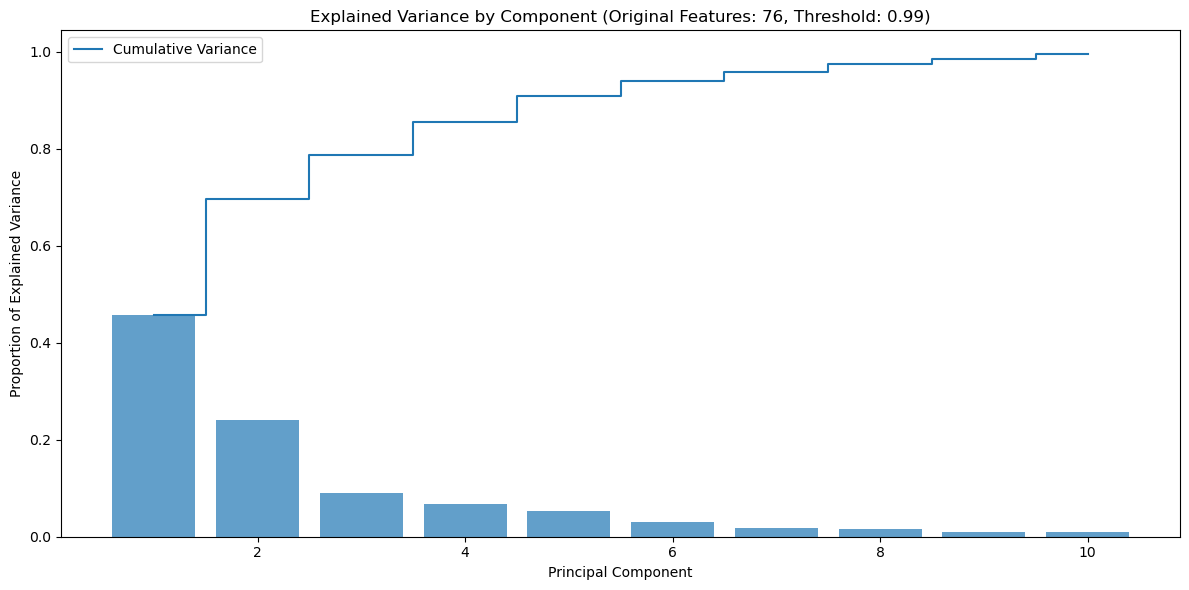

For the variance threshold 0.95:
  Number of original features: 76
  Number of selected principal components: 7
  Cumulative explained variance: 0.96



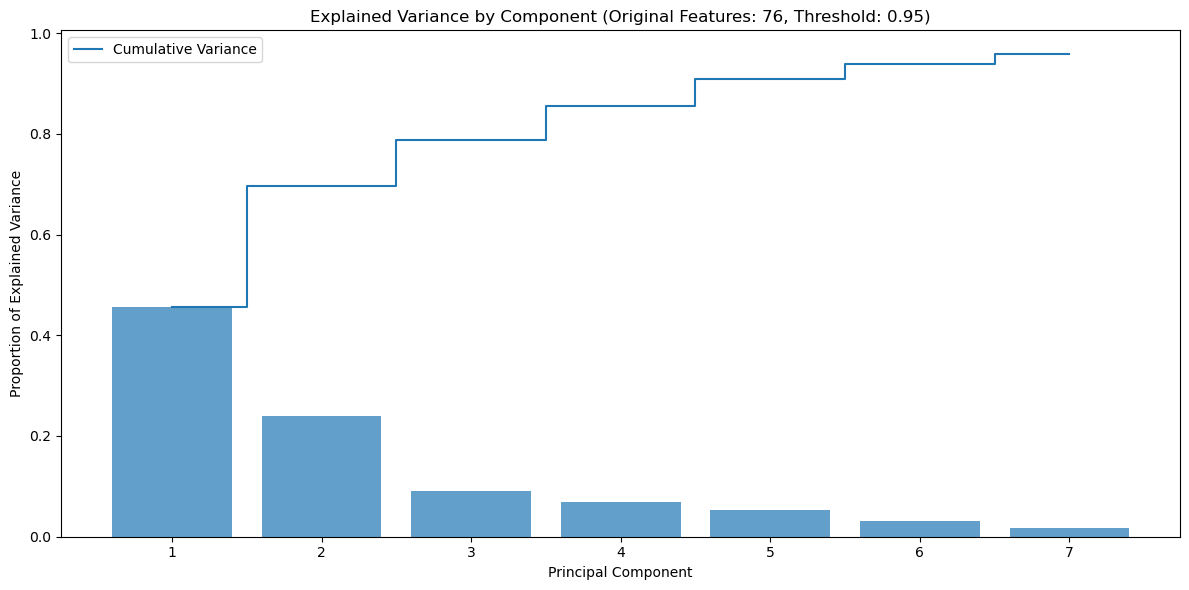

For the variance threshold 0.9:
  Number of original features: 76
  Number of selected principal components: 5
  Cumulative explained variance: 0.91



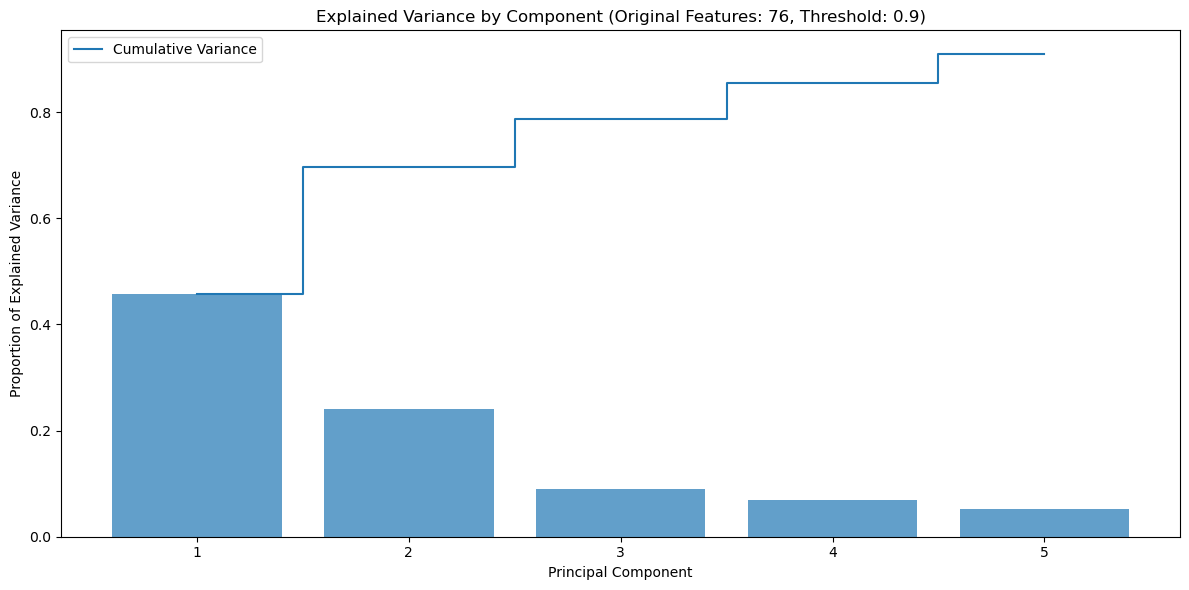

In [31]:
variance_thresholds = [0.99, 0.95, 0.90]

X_first_fold, y_first_fold = None, None
target = pd.Series(train_y)

for train_idx, test_idx in skf.split(train_x, target):
    X_first_fold, y_first_fold = train_x.iloc[train_idx], target.iloc[train_idx]
    break  


for threshold in variance_thresholds:
    pipeline = Pipeline([
        ('scaler', scaler),                
        ('smote',smote),            
        ('rus',rus),
        ('pca', PCA(n_components=threshold))          
    ])
    
    # Apply the pipeline to the first fold
    X_pca = pipeline.fit_transform(X_first_fold, y_first_fold)
    pca = pipeline.named_steps['pca']
    
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    n_components = pca.n_components_
  
    original_feature_count = X_first_fold.shape[1]

    print(f"For the variance threshold {threshold}:")
    print(f"  Number of original features: {original_feature_count}")
    print(f"  Number of selected principal components: {n_components}")
    print(f"  Cumulative explained variance: {cumulative_variance[-1]:.2f}")
    print()
    
    plt.figure(figsize=(12, 6))
    
    # Individual explained variance
    plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center')
    plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative Variance')
    
    plt.title(f'Explained Variance by Component (Original Features: {original_feature_count}, Threshold: {threshold})')

    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Explained Variance')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


## Considerations

After this phase, it becomes clear that by lowering the threshold for explained variance from 0.99 to 0.90, the number of principal components decreases from 10 to 5. Despite this reduction in dimensionality, the performance of the Linear Regressor remains strong, highlighting the model's robustness even with fewer components. The only metric that shows a slight decrease due to the reduction in components is the recall, which is primarily affected by the significant class imbalance. This indicates that most of the essential information is captured within the first few principal components, and a considerable reduction in dimensionality does not significantly impact the model's predictive power. This further underscores the effectiveness of PCA in maintaining high performance while reducing model complexity

# Step 5: Model evaluation and comparison between different models

The last step is to adopt different models whit the different techniques seen so far to confirm the expectations that independently of the model, the classification task is simple with this dataset and to demonstrate that with a lower number of features or dimensions the performances remain consistently high.

## Random Forest with Feature selection  
Training of Random Forest with the ten least important features, selected in the previous analysis.

In [32]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf_fs = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10))
])


metrics_df = evaluate_model(selected_features, train_y, pipeline_rf_fs, skf, scoring)
display(metrics_df)




Training Scores:
accuracy (train): [0.99325114 0.99309188 0.99411139 0.99412315 0.99445341 0.99370542
 0.99342346 0.99569483 0.99332164 0.99458786]
precision (train): [0.99998029 0.9999816  0.99998293 0.99998162 0.99998162 0.99998161
 0.99998029 0.99998033 0.99997897 0.99998162]
recall (train): [0.99327039 0.99310982 0.99412808 0.99414114 0.99447142 0.99372339
 0.99344272 0.99571421 0.9933422  0.99460588]
f1 (train): [0.99661405 0.99653386 0.99704691 0.99705282 0.99721891 0.99684268
 0.99670079 0.99784271 0.99664954 0.99728651]

Test Scores:
accuracy (test): [0.99333866 0.99322118 0.99349139 0.99402    0.99466617 0.99349131
 0.99318585 0.99588801 0.99306836 0.9944077 ]
precision (test): [0.99998817 0.99997634 0.9999527  0.99997636 0.99997638 0.99997635
 0.99998817 0.99996461 1.         0.99997637]
recall (test): [0.9933501  0.99324435 0.993538   0.99404321 0.99468941 0.9935145
 0.99319728 0.99592307 0.99306804 0.99443093]
f1 (test): [0.99665808 0.99659898 0.99673503 0.99700096 0.99732

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.993976,0.993878,0.999981,0.999978,0.993995,0.9939,0.996979,0.996929


## Random Forest with PCA
Training of Random Forest after adopting PCA with an explained variance of 0.99.

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Creazione della pipeline con RandomForest invece di LogisticRegression
pipeline_rf_pca = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('pca', PCA(n_components=0.99)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10))
])


metrics_df = evaluate_model(train_x, train_y, pipeline_rf_pca, skf, scoring)
display(metrics_df)



Training Scores:
accuracy (train): [0.99993081 0.99996084 0.99983552 0.99995301 0.99994909 0.99995953
 0.99989687 0.99977286 0.99995823 0.99993343]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99993081 0.99996084 0.99983551 0.999953   0.99994909 0.99995953
 0.99989687 0.99977285 0.99995823 0.99993342]
f1 (train): [0.9999654  0.99998042 0.99991775 0.9999765  0.99997454 0.99997977
 0.99994843 0.99988641 0.99997911 0.99996671]

Test Scores:
accuracy (test): [0.9999765  0.99995301 0.99982377 0.99994126 0.9999765  0.99996475
 0.99987077 0.99971804 0.99989426 0.99994126]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [0.9999765  0.999953   0.99982376 0.99994125 0.9999765  0.99996475
 0.99987076 0.99971802 0.99989426 0.99994125]
f1 (test): [0.99998825 0.9999765  0.99991187 0.99997063 0.99998825 0.99998238
 0.99993538 0.99985899 0.99994713 0.99997063]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999915,0.999906,1.0,1.0,0.999915,0.999906,0.999958,0.999953


## XGBoost with Feature Selection
Training of XGBoost with the ten least important features, selected in the previous analysis.

In [34]:
from xgboost import XGBClassifier

pipeline_xgb_fs = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('classifier', XGBClassifier(random_state=42, n_estimators=100, max_depth=10, eval_metric='logloss'))
])

metrics_df = evaluate_model(selected_features, train_y, pipeline_xgb_fs, skf, scoring)
display(metrics_df)



Training Scores:
accuracy (train): [0.99375371 0.99388947 0.9940657  0.99327073 0.99494946 0.99322634
 0.99400697 0.99526405 0.99403046 0.99517268]
precision (train): [0.9999803  0.99998161 0.99998293 0.9999816  0.99998163 0.9999816
 0.9999803  0.99998033 0.99997899 0.99998164]
recall (train): [0.99377299 0.99390745 0.99408239 0.99328868 0.99496749 0.99324429
 0.99402626 0.99528341 0.99405106 0.99519072]
f1 (train): [0.99686698 0.99693528 0.99702393 0.9966239  0.99746826 0.99660156
 0.99699439 0.99762634 0.99700621 0.99758043]

Test Scores:
accuracy (test): [0.99402007 0.99411405 0.99350314 0.99320935 0.99511261 0.99306836
 0.99387901 0.99548856 0.99379677 0.99510086]
precision (test): [0.99998818 0.99997636 0.9999527  0.99997634 0.99997639 0.99997634
 0.99998818 0.9999646  1.         0.99997639]
recall (test): [0.99403153 0.99413727 0.99354975 0.99323253 0.99513588 0.99309154
 0.99389048 0.9955236  0.99379648 0.99512413]
f1 (test): [0.99700096 0.99704827 0.99674094 0.99659303 0.99755

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.994163,0.994129,0.999981,0.999978,0.994181,0.994151,0.997073,0.997056


## XGBoost with PCA
Training of Random Forest after adopting PCA with an explained variance of 0.99.

In [35]:

pipeline_xgb_pca = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),
    ('pca', PCA(n_components=0.99)),
    ('classifier', XGBClassifier(random_state=42, n_estimators=100, max_depth=10, eval_metric='logloss'))
])


metrics_df = evaluate_model(train_x, train_y, pipeline_xgb_pca, skf, scoring)
display(metrics_df)



Training Scores:
accuracy (train): [0.99986424 0.99975198 0.99965929 0.99985771 0.99950004 0.99994517
 0.99987599 0.99904185 0.999782   0.99943868]
precision (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (train): [0.99986423 0.99975196 0.99965928 0.99985771 0.99950001 0.99994517
 0.99987598 0.9990418  0.99978199 0.99943866]
f1 (train): [0.99993211 0.99987597 0.99982961 0.99992885 0.99974994 0.99997258
 0.99993799 0.99952067 0.99989098 0.99971925]

Test Scores:
accuracy (test): [0.99990601 0.99984727 0.99969454 0.99989426 0.99943607 0.99994126
 0.99983552 0.9991776  0.99965929 0.99930684]
precision (test): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
recall (test): [0.99990601 0.99984726 0.99969452 0.99989426 0.99943604 0.99994125
 0.99983551 0.99917756 0.99965928 0.9993068 ]
f1 (test): [0.999953   0.99992363 0.99984724 0.99994713 0.99971794 0.99997063
 0.99991775 0.99958861 0.99982961 0.99965328]


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,0.999672,0.99967,1.0,1.0,0.999672,0.99967,0.999836,0.999835


## Performance Evaluation with ROC AUC curve

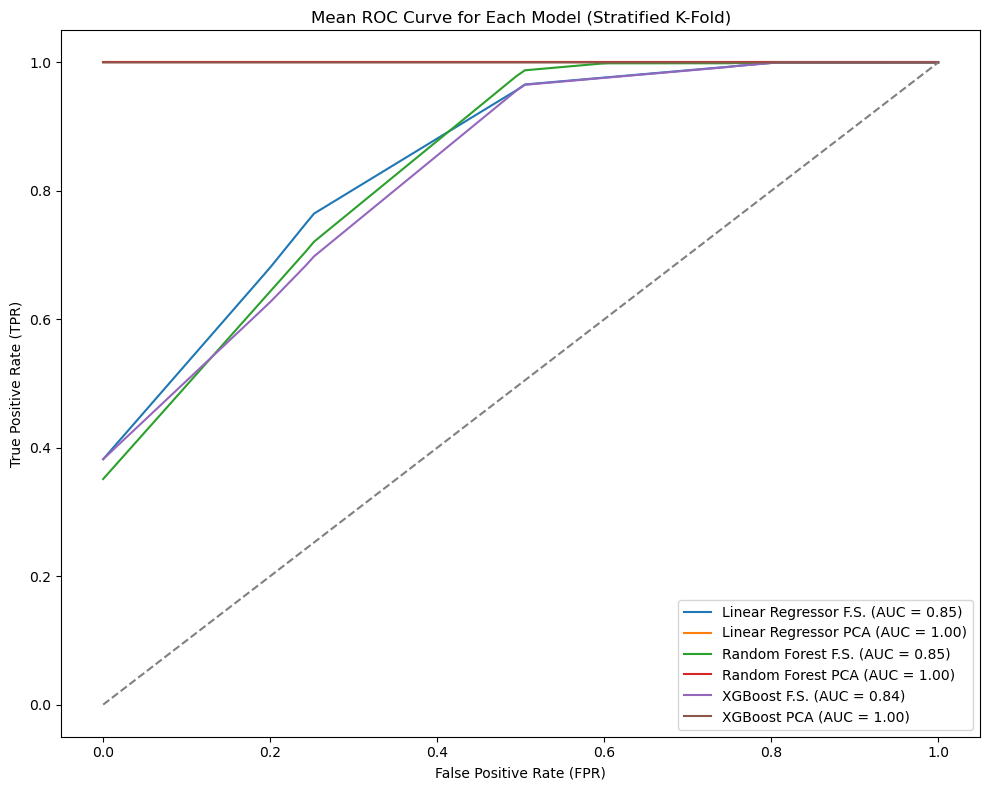

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

target = pd.Series(train_y)
pipelines = [pipeline_no_selection, pipeline_pca_99, pipeline_rf_fs, pipeline_rf_pca, pipeline_xgb_fs ,pipeline_xgb_pca]

pipeline_labels = ['Linear Regressor F.S.', 'Linear Regressor PCA', 'Random Forest F.S.', 'Random Forest PCA', 'XGBoost F.S.', 'XGBoost PCA']
plt.figure(figsize=(10, 8))

for i, pipeline in enumerate(pipelines):
    # Store true positive and false positive rates for each fold
    tprs = []
    fprs = []
    aucs = []

    
    if i in [0, 2, 4]:
        train_data= selected_features
    else:
        train_data= train_x
        
    for train_index, test_index in skf.split(train_data, target):
        X_train, X_test = train_data.iloc[train_index], train_data.iloc[test_index]
        y_train, y_test = target.iloc[train_index], target.iloc[test_index]

        pipeline.fit(X_train, y_train)
        
        # Predict probabilities for the positive class
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        
        # Interpolate the ROC curve
        mean_fpr = np.linspace(0, 1, 100)  
        mean_tpr = np.interp(mean_fpr, fpr, tpr)
        
        # Calculate AUC
        auc = roc_auc_score(y_test, y_prob)
        
        tprs.append(mean_tpr)
        fprs.append(mean_fpr)
        aucs.append(auc)
    
    # Calculate the mean ROC curve
    mean_tpr = np.mean(tprs, axis=0)
    mean_fpr = np.mean(fprs, axis=0)
    
    # Plot the ROC curve for each fold, and the mean ROC curve
    plt.plot(mean_fpr, mean_tpr, label=f'{pipeline_labels[i]} (AUC = {np.mean(aucs):.2f})')

# Add a random chance line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Add labels and legend
plt.title('Mean ROC Curve for Each Model (Stratified K-Fold)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()


## Considerations

In the final analysis, two additional classifiers, **Random Forest** and **XGBoost**, are trained and compared alongside the initial model. The goal is to assess whether different models exhibit distinct behaviors when applied to the same dataset.

As expected, the performance differences are not primarily due to the choice of model but are instead influenced by modifications to the features set. The analysis demonstrates that **Random Forest**, **Linear Regressor**, and **XGBoost** exhibit similar behavior, with their performance being predominantly determined by the dimensionality reduction method applied.

# Final Results
The setted goal of this project was to train a classifier to be able to correclty classify bad connections from the good ones, even whitout having a complete set of features.  
This leads to firstly analyze the different rebalancing techniques and then to analyze the dimensionality reduction, adopting both feature importance and PCA to understand how the performance are affected, ending whit a confrontation of different classifiers to show that independently from the model, the perfomance, related to this particular dataset, are only affected from the modification of the features set.  
The conclusions are:

- **Rebalancing does not affect the performance** : Adopting different rebalancing techniques, even including transformed numeric features, does not impact the performance of the model, which enlight the fact that the difference in values from istances of different classes is such that, even creating a lot of fictional istances, the distinction between the two remains clear.
- **The model uses just few features to classify**: After the analysis on the feature importance, it's possible to notice that the model adopt just one or few features to take the decision. This is a remarkable aspect because it ensure that the model, even lacking of most of the feature, is able to correctly classify an unseen istance.
- **Dimensions can be reduced even with PCA**: Another key observation is that dimensionality can be effectively reduced using Principal Component Analysis (PCA) without substantially affecting performance. However, doing so eliminates the connections between features and the original data. Consequently, adopting PCA in a real-world context might not be ideal, as it would prevent the monitoring and removal of redundant features, which is otherwise possible
- **Other classifier behaves as well as the regressor**: Given the simplicity of the problem with this dataset, other classifiers, even complex ones, can achieve similarly effective performance in the classification task.

# Future Implementations
A lot of future implementations and development are possible for this technology. One possibility is to create a real-time validator of connections by training the model with different dataset, representing different possible attacks and use it for the protection of critical resources. In a real-time context the model may not be provided with all of the features that are represented in this dataset, but it's proved that even having a small sub set of features, the model is able to classify correclty all of the unseen istances.  
## XAI
Another techinques that can be usefull for future implementation is the adoption of some models for the "eXplainable Artificial Intelligence", such as SHAP. By using those approaches it's possible to better understand how the model takes decisions and maybe sets some necessary features that should always be presents and monitored to gain an high level of security. An application of SHAP to this case is presented above. 



# Use of SHAP for XAI

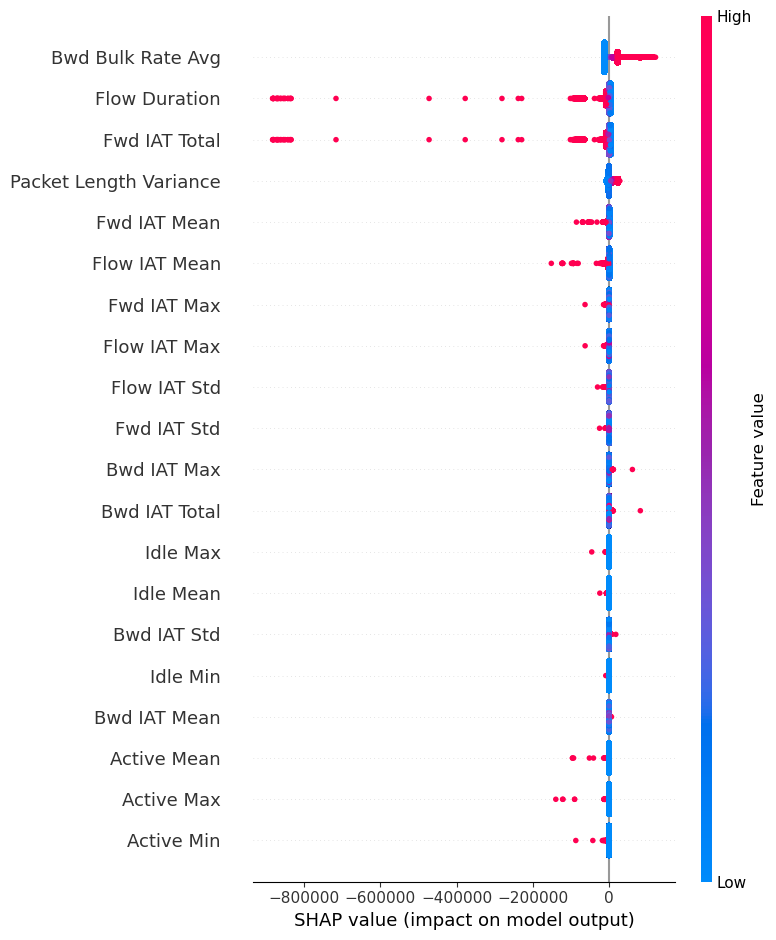

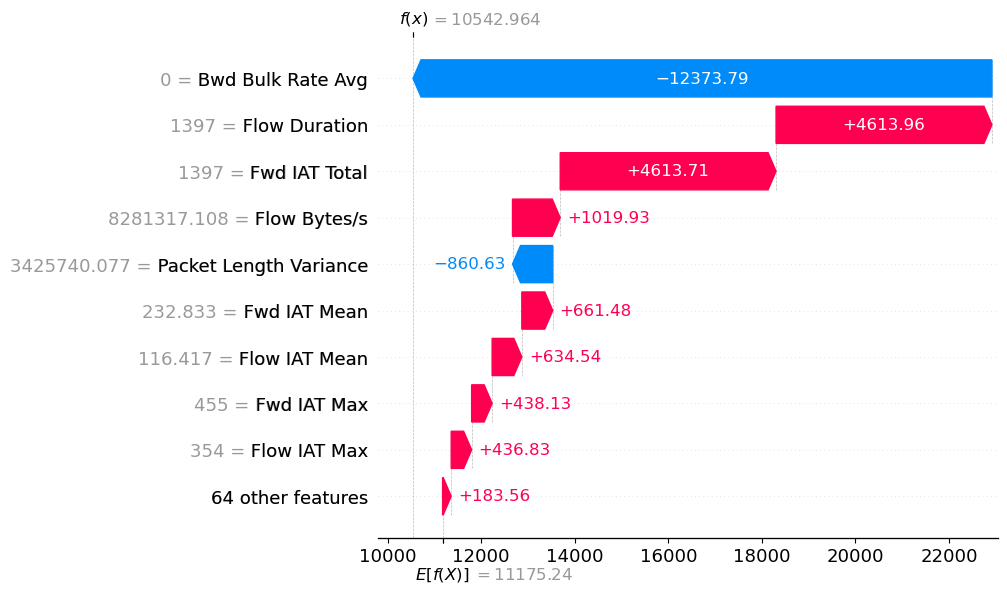

In [37]:
import shap

pipeline_no_selection = Pipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('rus', rus),      
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

scoring = ['accuracy', 'precision', 'recall', 'f1']

train_x_num = train_x.drop(['Hour', 'Weekday', 'Month'], axis=1)

pipeline_no_selection.fit(train_x_num, train_y)

explainer = shap.LinearExplainer(pipeline_no_selection.named_steps['classifier'], train_x_num)

shap_values = explainer.shap_values(train_x_num)

shap.summary_plot(shap_values, train_x_num)

instance_idx = 0
instance = train_x_num.iloc[instance_idx]

shap.waterfall_plot(shap.Explanation(values=shap_values[instance_idx],
                                     base_values=explainer.expected_value,
                                     data=instance,
                                     feature_names=train_x_num.columns))


The analysis with SHAP reveals that certain features, such as Bwd Bulk Rate Avg, Flow Duration, and Fwd IAT Total, are crucial for the model, as they contribute most significantly to the predictions. Even in the presence of other features, the model primarily relies on these to correctly distinguish between the classes. Therefore, their inclusion is essential to maintain high performance and to provide valuable insights for interpretation.